In [1]:
%matplotlib inline
import sys
sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.gridspec as gridspec

from src import (
    load_experiment, get_transform, get_loaders_from_config,
    collect_layer_inputs,
    bft,
    auto_nmf_pipeline,
    nmf_component_sweep,
    plot_scaffold_graph,
    evaluate,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


In [2]:
import os
import os as _os

_FIG_ROOT = _os.path.join(_os.path.dirname(_os.path.abspath('.')), 'figs')
# Per-experiment fig dirs are created in the config cell below (after EXPERIMENT_DIR is set)

# Notebook 02: Backward Factor Trace

This notebook implements a **backward factor-tracing algorithm** through the trained SimpleMLP.

## Algorithm

Starting at the output layer and working backwards to the pixel inputs:

1. **Last layer**: For each output neuron, compute its synaptic arbor against the L2-normalised previous-layer activations.  Concatenate all arbors horizontally and run NMF.  The top factor's stimulus weights propagate backwards.
2. **Each preceding layer**: Compute arbors against L2-normalised inputs, rescale each sample's rows by the incoming stimulus weights, zero out rows where `stimulus_weight ≤ STIMULUS_THRESHOLD`, concatenate, run NMF, pass top factor stimulus weights to the next layer back.
3. **Layer 1**: Arbors are pixel-level — the top factor's neural pattern is a set of 28×28 receptive fields, one per L1 neuron.

The result is a chain of per-layer NMF factors revealing the principal computational pathway through the network.

## Section 1: Setup

In [3]:
# Change EXPERIMENT_DIR to switch models
EXPERIMENT_DIR    = '../experiments/mnist_even_odd_mlp_8_4_0134'; N_BRANCHES = [10, 2, 2]
#EXPERIMENT_DIR    = '../experiments/mnist_even_odd_mlp_10_5_0134'; N_BRANCHES = [10, 4, 2]
#EXPERIMENT_DIR    = '../experiments/mnist_even_odd_mlp_10_5'; N_BRANCHES = [10, 4, 2]
#EXPERIMENT_DIR    = '../experiments/mnist_digit_mlp_40_20'; N_BRANCHES = [1, 1, 10]

# Derive figure directories from experiment name so re-runs don't overwrite
EXP_NAME   = os.path.basename(EXPERIMENT_DIR.rstrip('/'))
_exp_root  = os.path.join(_FIG_ROOT, '02_factor_trace', EXP_NAME)
FIG_KSWEEP = os.path.join(_exp_root, 'k_sweep')
FIG_FVIZ   = os.path.join(_exp_root, 'factor_viz')
FIG_PIXRF  = os.path.join(_exp_root, 'pixel_receptive_fields')
FIG_SCAFF  = os.path.join(_exp_root, 'scaffold_graphs')
for _d in [FIG_KSWEEP, FIG_FVIZ, FIG_PIXRF, FIG_SCAFF]:
    os.makedirs(_d, exist_ok=True)
print(f'fig dirs ready under {_exp_root}')


# K_MAX_PER_LAYER: upper bound on NMF rank for auto-selection, indexed L1-first.
# auto_nmf_pipeline selects the effective K* ≤ k_max based on the criteria below.
# Use None for a layer to fall back to the default (min(min(X.shape)-1, 20)).
K_MAX_PER_LAYER   = [20, 15, 15]   # [L1 (pixel), L2, L3 (output)]

# Auto-selection hyperparameters
#   AUTO_METHOD:
#     'cumvar'     — keep fewest K covering AUTO_THRESHOLD of cumulative λ
#     'marginal'   — keep K while λ[k]/λ[0] >= AUTO_THRESHOLD
#     'elbow'      — K at inflection of λ curve (no threshold)
#     'fraction'   — K at first consecutive-ratio drop >= 1.5
#     'structural' — fraction as primary signal, with cumvar floor at AUTO_THRESHOLD
#                    (recommended: robust across different λ-curve shapes)
#     list e.g. ['elbow', 'cumvar'] — same as 'structural' but with elbow as primary
AUTO_METHOD       = 'structural'  # recommended default
AUTO_THRESHOLD    = 0.70          # cumvar floor for 'structural'; fraction/elbow used for shape

# AUTO_MIN_CUMVAR: explicit cumvar floor when using a single structural method.
# None = ignored (threshold acts as the floor when AUTO_METHOD='structural').
AUTO_MIN_CUMVAR   = None

STIMULUS_THRESHOLD = 0.7  # fraction [0,1): zero out lowest X% of stimuli by weight
N_VIZ             = 4     # number of top factors to visualize per layer

model, cfg = load_experiment(EXPERIMENT_DIR, device)
train_loader, test_loader = get_loaders_from_config(cfg)
label_transform = get_transform(cfg['label_transform'])

import torch.nn as nn
_, test_acc = evaluate(model, test_loader,
                       criterion=nn.CrossEntropyLoss(),
                       label_transform=label_transform, device=device)
print(f'Test accuracy: {test_acc:.4f}')

linear_indices = model.linear_layer_indices()
LAYER_SIZES    = [model.layers[li].out_features for li in linear_indices]
N_LAYERS       = len(LAYER_SIZES)
IMAGE_SIDE     = cfg['input_side']
CLASS_NAMES = ({0: 'even', 1: 'odd'} if cfg['label_transform'] == 'even_odd' else {i: str(i) for i in range(LAYER_SIZES[-1])})

assert len(K_MAX_PER_LAYER) == N_LAYERS, \
    f"K_MAX_PER_LAYER has {len(K_MAX_PER_LAYER)} entries but model has {N_LAYERS} layers"

print(f'Architecture (neurons per layer): {LAYER_SIZES}')
print(f'Linear layer indices in model.layers: {linear_indices}')
print(f'K_MAX_PER_LAYER: {K_MAX_PER_LAYER}  method={AUTO_METHOD!r}  threshold={AUTO_THRESHOLD}  min_cumvar={AUTO_MIN_CUMVAR}')
print(model)

fig dirs ready under /Users/johannesbertram/repos/Weight_Interpretability/figs/02_factor_trace/mnist_even_odd_mlp_8_4_0134
Test accuracy: 0.9929
Architecture (neurons per layer): [8, 4, 2]
Linear layer indices in model.layers: [1, 3, 5]
K_MAX_PER_LAYER: [20, 15, 15]  method='structural'  threshold=0.7  min_cumvar=None
SimpleMLP(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=8, bias=True)
    (2): Sigmoid()
    (3): Linear(in_features=8, out_features=4, bias=True)
    (4): Sigmoid()
    (5): Linear(in_features=4, out_features=2, bias=True)
    (6): Softmax(dim=-1)
  )
)


## Section 2: Collect Layer Data

`collect_layer_inputs` collects, for each correctly-classified **test** sample:
- the raw image
- the **inputs** to each linear layer (needed for arbor computation)
- the **post-activation outputs** of each linear layer

In [4]:
data = collect_layer_inputs(
    model, test_loader.dataset,
    label_transform=label_transform,
    n_per_class=None,   # use all correctly-classified samples
    device=device,
)

all_images   = data['images']        # (n, C, H, W)
all_targets  = data['targets']       # (n,) task labels
all_digits   = data['digits']        # (n,) original digit labels
layer_inputs = data['layer_inputs']  # list[(n, n_in)] — pixel inputs first
layer_acts   = data['layer_acts']    # list[(n, n_out)]
n_samples    = len(all_images)

print(f'Total samples collected: {n_samples}')
print(f'Class distribution: {dict(zip(*np.unique(all_targets, return_counts=True)))}')
print()
for i, (li, la) in enumerate(zip(layer_inputs, layer_acts)):
    print(f'  L{i+1} inputs: {li.shape}  |  L{i+1} activations: {la.shape}')

Total samples collected: 4078
Class distribution: {np.int64(0): np.int64(1946), np.int64(1): np.int64(2132)}

  L1 inputs: (4078, 784)  |  L1 activations: (4078, 8)
  L2 inputs: (4078, 8)  |  L2 activations: (4078, 4)
  L3 inputs: (4078, 4)  |  L3 activations: (4078, 2)


## Section 3: Run the Backward Factor Trace

`bft` (with `n_branches=1`) applies the algorithm from the last layer backwards:

- Initialises stimulus weights to uniform (ones)
- At each layer: computes normalised joint arbors (rows with `stimulus_weight ≤ STIMULUS_THRESHOLD` zeroed), runs NMF, extracts top factor
- The top factor's `img_factors[:, 0]` becomes the stimulus weights for the preceding layer

In [5]:
tree_root = bft(model, layer_inputs,
                       k_max=K_MAX_PER_LAYER, n_branches=N_BRANCHES,
                       method=AUTO_METHOD, threshold=AUTO_THRESHOLD,
                       min_cumvar=AUTO_MIN_CUMVAR,
                       stimulus_threshold=STIMULUS_THRESHOLD)

# Spine: follow first child at each depth — used by Sections 3.5, 5, 7
def _spine(root):
    chain = [root]
    node = root
    while node['children']:
        node = node['children'][0]
        chain.append(node)
    return chain

trace_results = _spine(tree_root)  # [last_layer, ..., first_layer]

print('Trace results (last → first layer):')
print(f'{"Layer":<8} {"W shape":<14} {"joint arbor":<20} {"K* selected":>12} {"top λ":>10} {"stim_w range"}')
print('-' * 80)
for r in trace_results:
    l  = r['layer_idx']
    W  = r['W']
    sw = r['stimulus_weights_in']
    k_star = r['lambdas'].shape[0]
    km = K_MAX_PER_LAYER[l]
    print(f"L{l+1:<7} {str(W.shape):<14} {str(r['joint_arbor'].shape):<20}"
          f" {k_star:>5}/{km!s:<6} {r['lambdas'][0]:>10.3f}  [{sw.min():.4f}, {sw.max():.4f}]")

/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 20000 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 20000 reached. Increase it to improve convergence.
  warnings.warn(


Trace results (last → first layer):
Layer    W shape        joint arbor           K* selected      top λ stim_w range
--------------------------------------------------------------------------------
L3       (2, 4)         (4078, 8)                6/15         48.404  [1.0000, 1.0000]
L2       (4, 8)         (4078, 32)               1/15          8.556  [0.0000, 0.1820]
L1       (8, 784)       (4078, 6272)            19/20          0.318  [0.0000, 0.0985]


In [6]:
from collections import deque

def get_nodes_by_depth(root):
    """BFS; returns {depth: [node,...]} where depth 0 = last layer."""
    by_depth = {}
    queue = deque([(root, 0)])
    while queue:
        node, d = queue.popleft()
        by_depth.setdefault(d, []).append(node)
        for child in node['children']:
            queue.append((child, d + 1))
    return by_depth

def get_all_paths(root):
    """All root-to-leaf paths as lists of nodes (last-layer-first)."""
    if not root['children']:
        return [[root]]
    return [[root] + p for child in root['children'] for p in get_all_paths(child)]

nodes_by_depth = get_nodes_by_depth(tree_root)
all_paths = get_all_paths(tree_root)
print(f'Tree: {len(nodes_by_depth)} depths, '
      f'{sum(len(v) for v in nodes_by_depth.values())} total nodes, '
      f'{len(all_paths)} paths')


Tree: 3 depths, 5 total nodes, 2 paths


## Section 3.5: K Sweep — Choose Number of Components per Layer

Run NMF at different ranks on each layer's **weighted joint arbor** (the actual matrix used during the trace).
Look for the elbow to choose a good K for each layer.

> Note: L1 has a large joint arbor (n × 7840).  Subsampling to `SWEEP_MAX_SAMPLES` rows keeps the sweep fast.

In [7]:
if False:
    SWEEP_MAX_SAMPLES = None   # subsample rows for speed; set to None to use all
    K_MAX_SWEEP       = 25     # maximum K to try

    rng = np.random.default_rng(0)

    # layer_order: first→last so plots read left=L1, right=L_last
    layer_order = list(reversed(trace_results))

    fig, axes = plt.subplots(1, N_LAYERS, figsize=(5 * N_LAYERS, 4))
    axes = np.array(axes).flatten()

    for ax, r in zip(axes, layer_order):
        l_idx = r['layer_idx']
        joint = r['joint_arbor']  # (n_samples, n_out * n_in)

        # subsample rows for tractability
        if SWEEP_MAX_SAMPLES is not None and joint.shape[0] > SWEEP_MAX_SAMPLES:
            idx = rng.choice(joint.shape[0], SWEEP_MAX_SAMPLES, replace=False)
            joint_sw = joint[idx]
        else:
            joint_sw = joint

        k_max = min(K_MAX_SWEEP, min(joint_sw.shape) - 1)
        k_range = range(1, k_max + 1)
        scree = nmf_component_sweep(joint_sw, k_range)

        ks  = sorted(scree.keys())
        evs = [scree[k] for k in ks]
        ax.plot(ks, evs, 'bo-', markersize=4, lw=1.5)
        km = K_MAX_PER_LAYER[l_idx]
        ax.axvline(km, color='r', ls='--', lw=1.5, label=f'k_max={km}')
        ax.set(xlabel='K (components)', ylabel='explained variance',
            title=f'L{l_idx+1} — K sweep\n({joint_sw.shape[0]} rows × {joint_sw.shape[1]} dims)')
        ax.set_xticks(ks)
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    fig.suptitle('K Sweep — Explained Variance of Weighted Joint Arbors\n'
                '(auto-selection picks K* at cumvar threshold; k_max marked in red)', fontsize=11)
    plt.tight_layout()
    fig.savefig(os.path.join(FIG_KSWEEP, 'k_sweep.pdf'), bbox_inches='tight')
    plt.show()

## Section 4: Per-Layer Factor Visualizations

For each layer (last → first), top **`N_VIZ` factors** are shown:
- **Row 0** — lambda bar chart, stimulus weights histogram, class-separation scatter
- **Rows 1–N_VIZ** — per factor: weighted average image, neural factor heatmap (`n_out × n_in`), top-4 highest-weighted samples

Only factor 0 drives the backward propagation; factors 1 and 2 are shown for comparison.

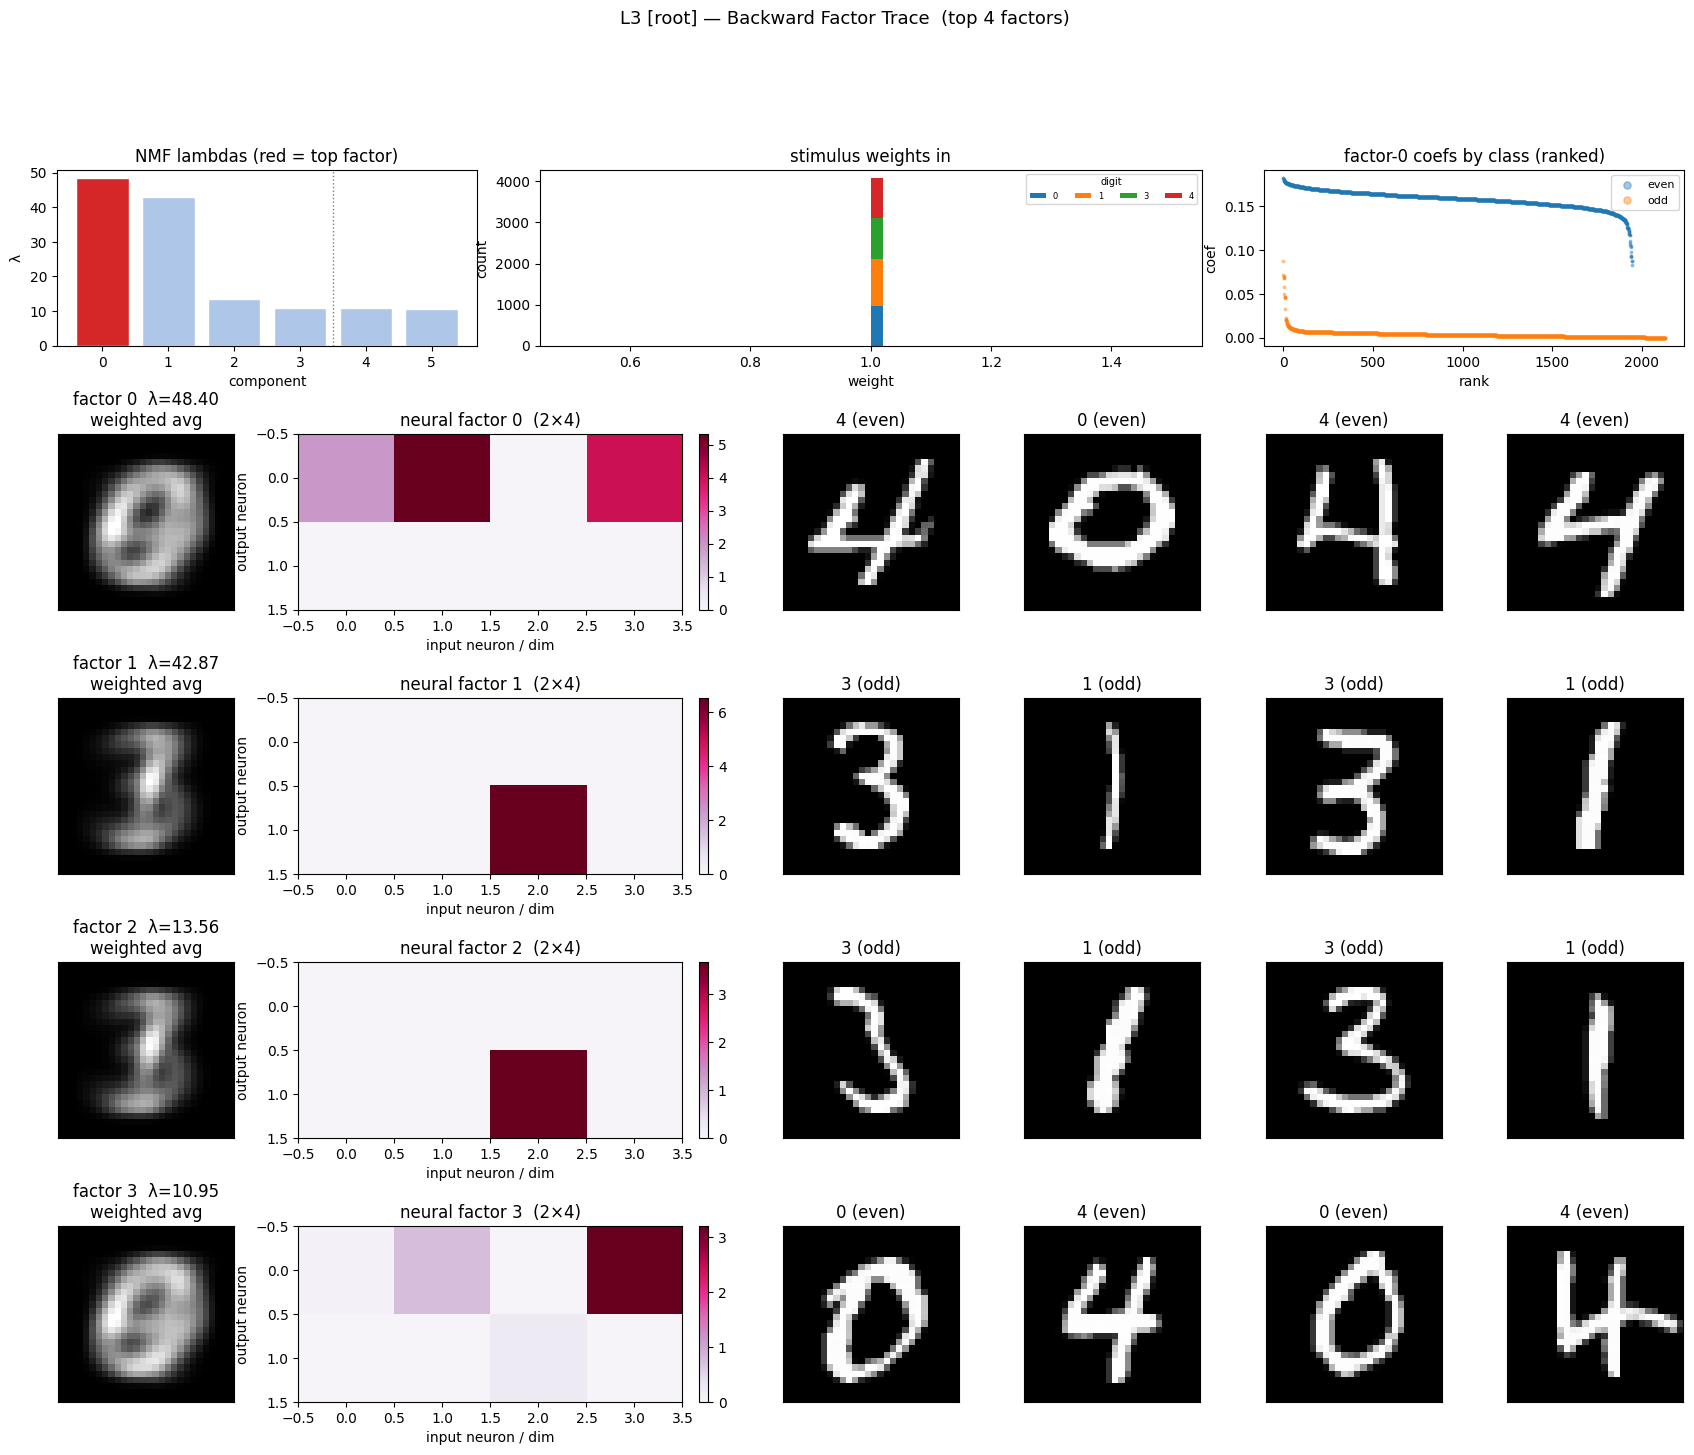

L3 — top 4 lambdas: [48.404 42.867 13.559 10.95 ]



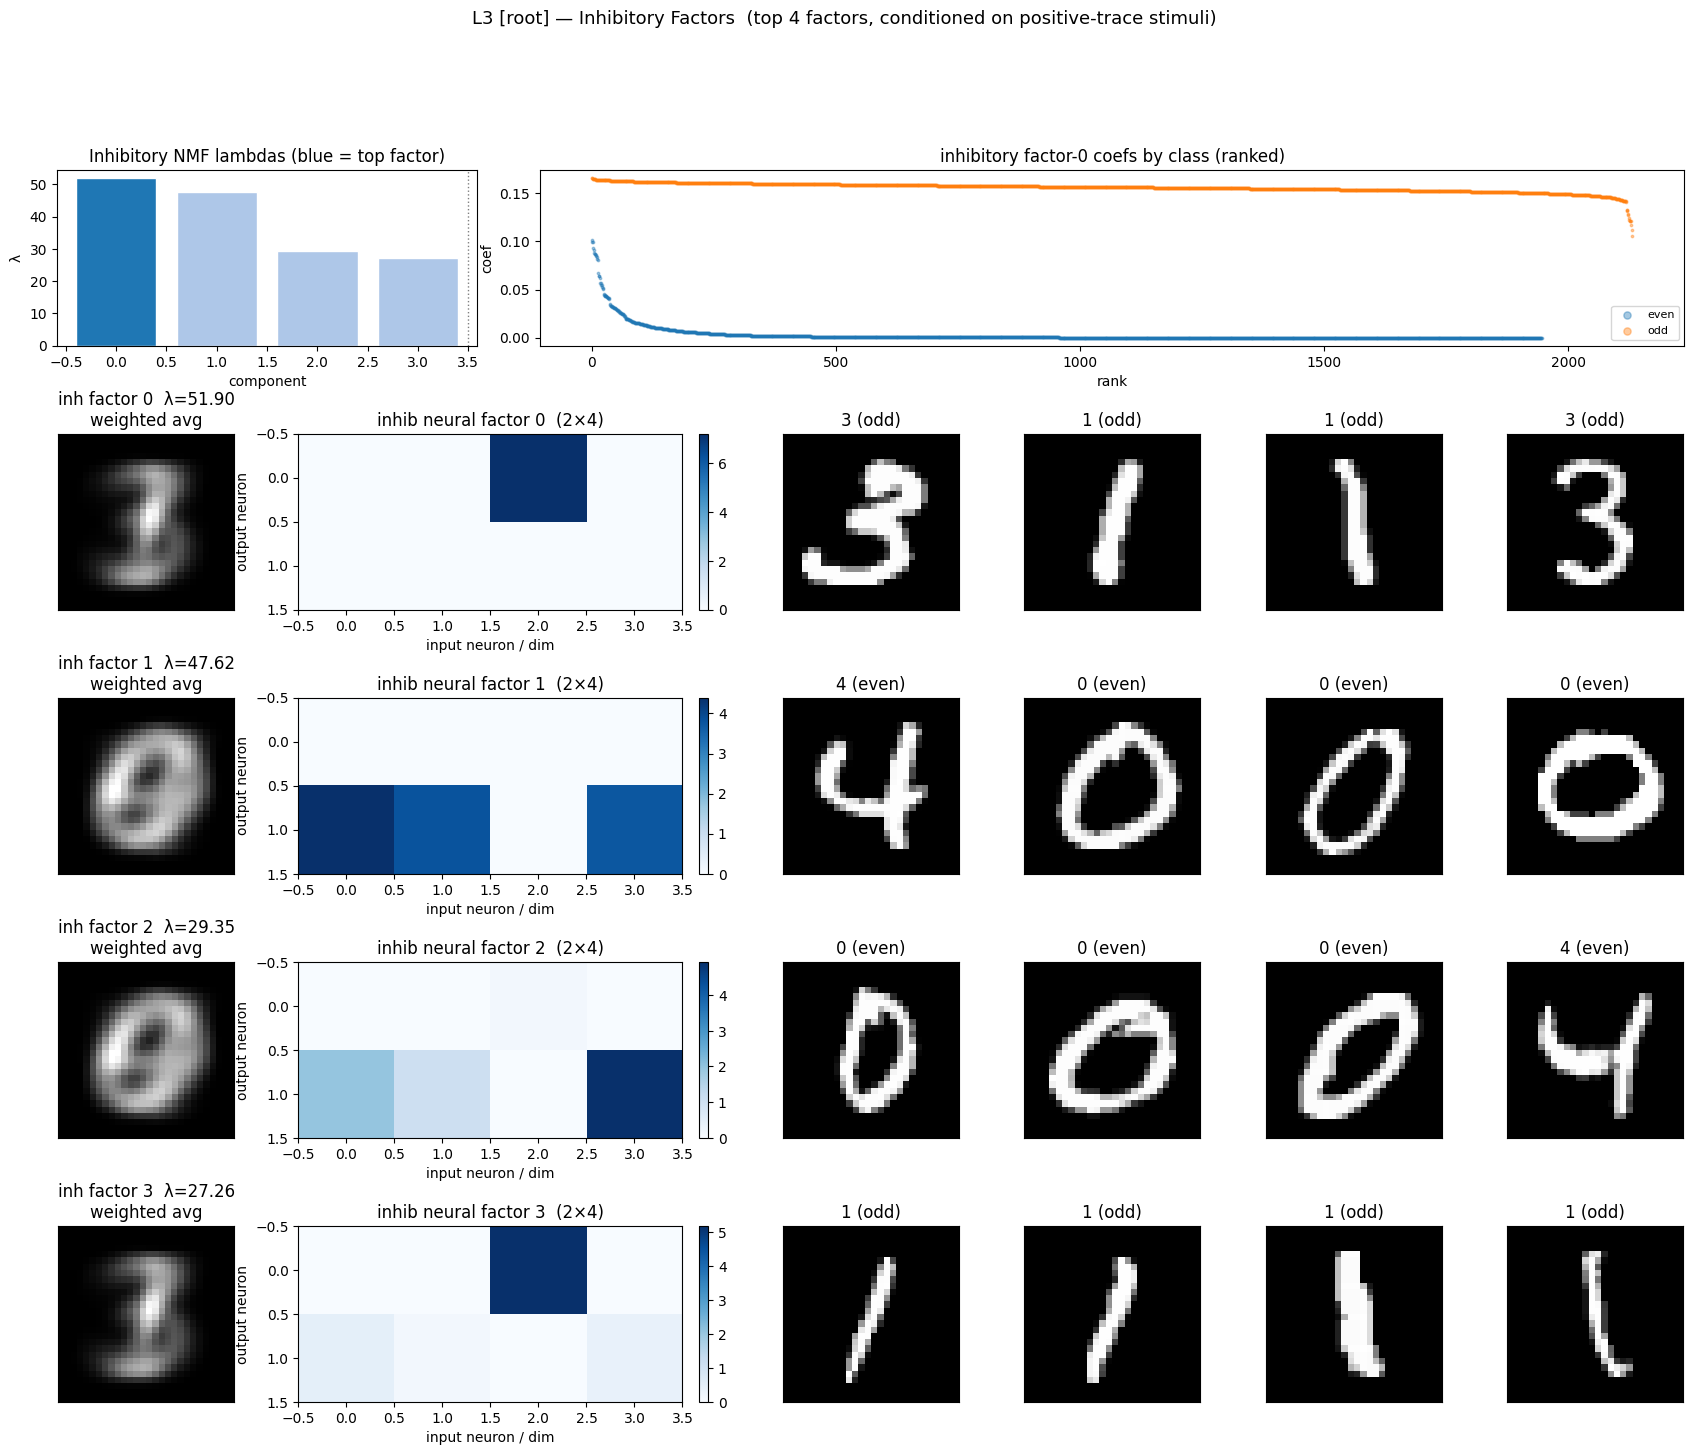

L3 inhibitory — top 4 lambdas: [51.897 47.624 29.354 27.257]



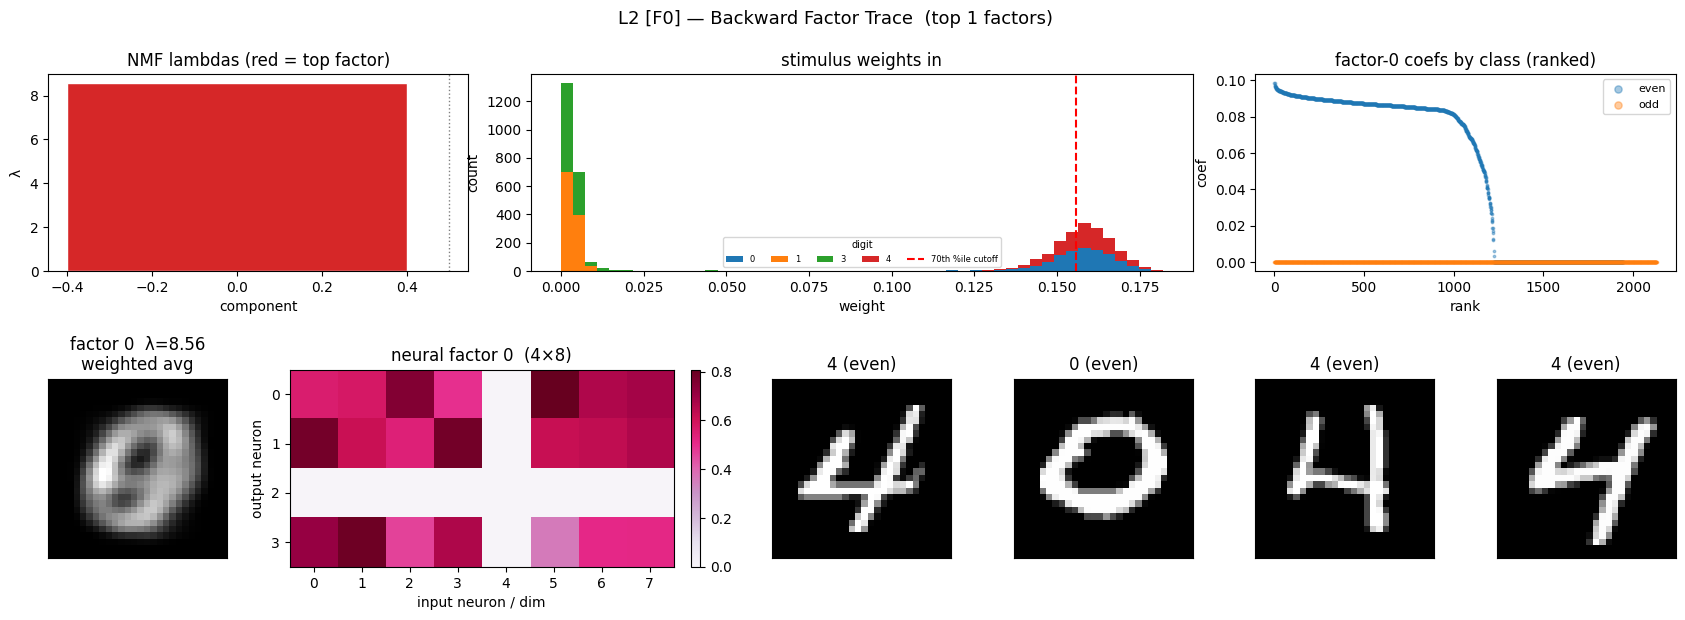

L2 — top 1 lambdas: [8.556]



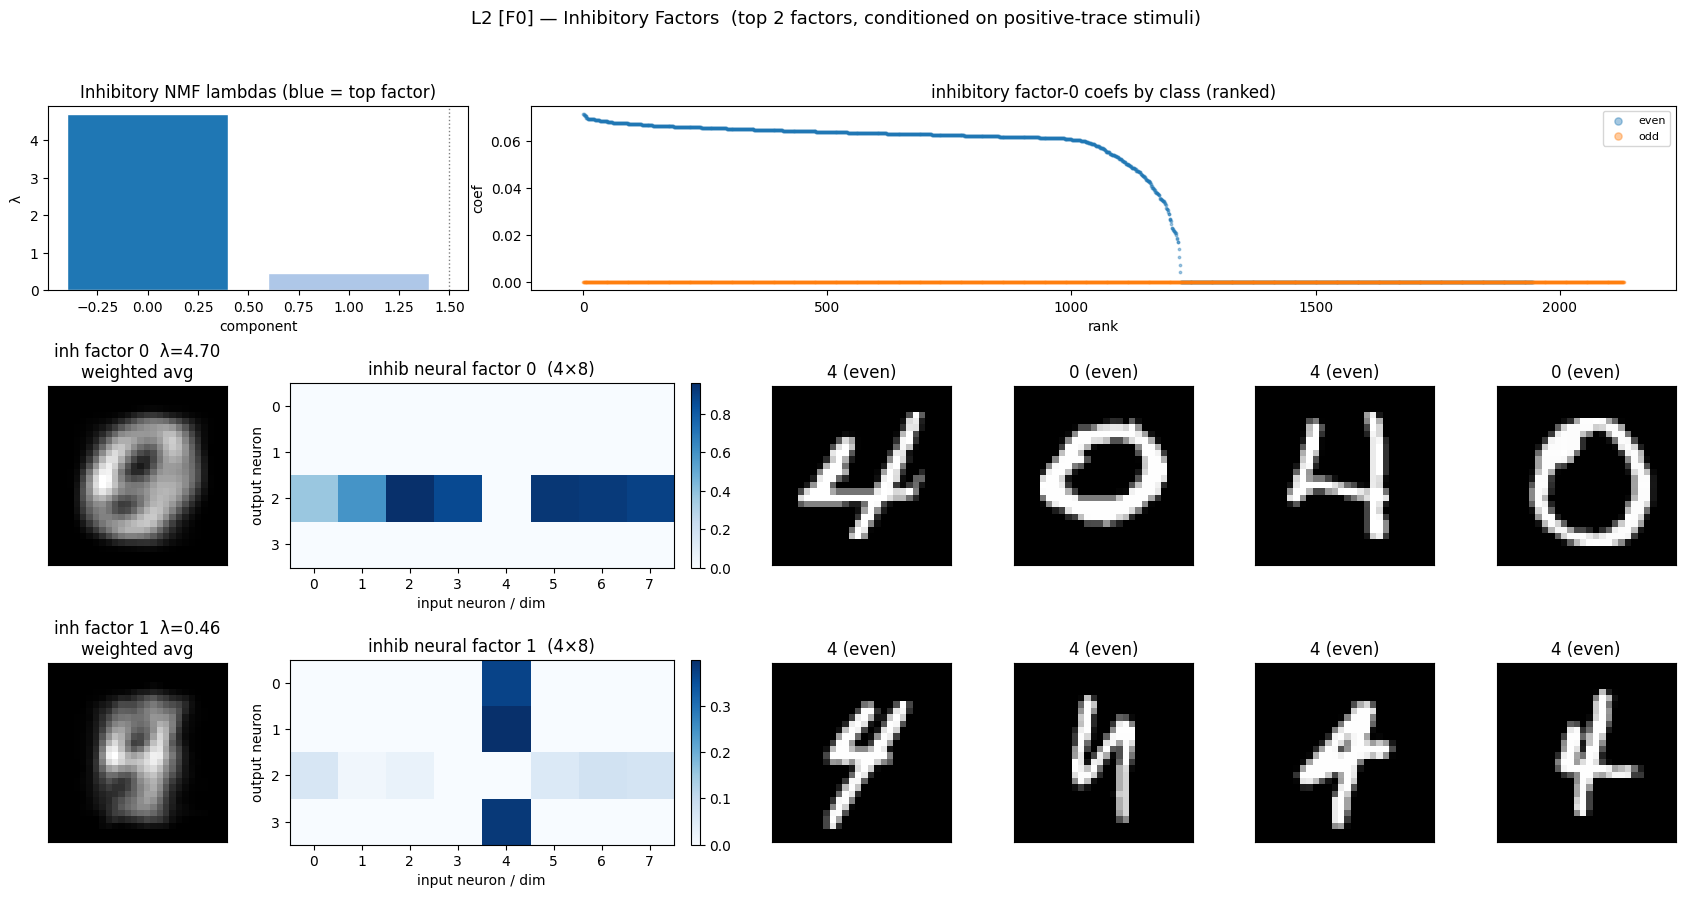

L2 inhibitory — top 2 lambdas: [4.698 0.464]



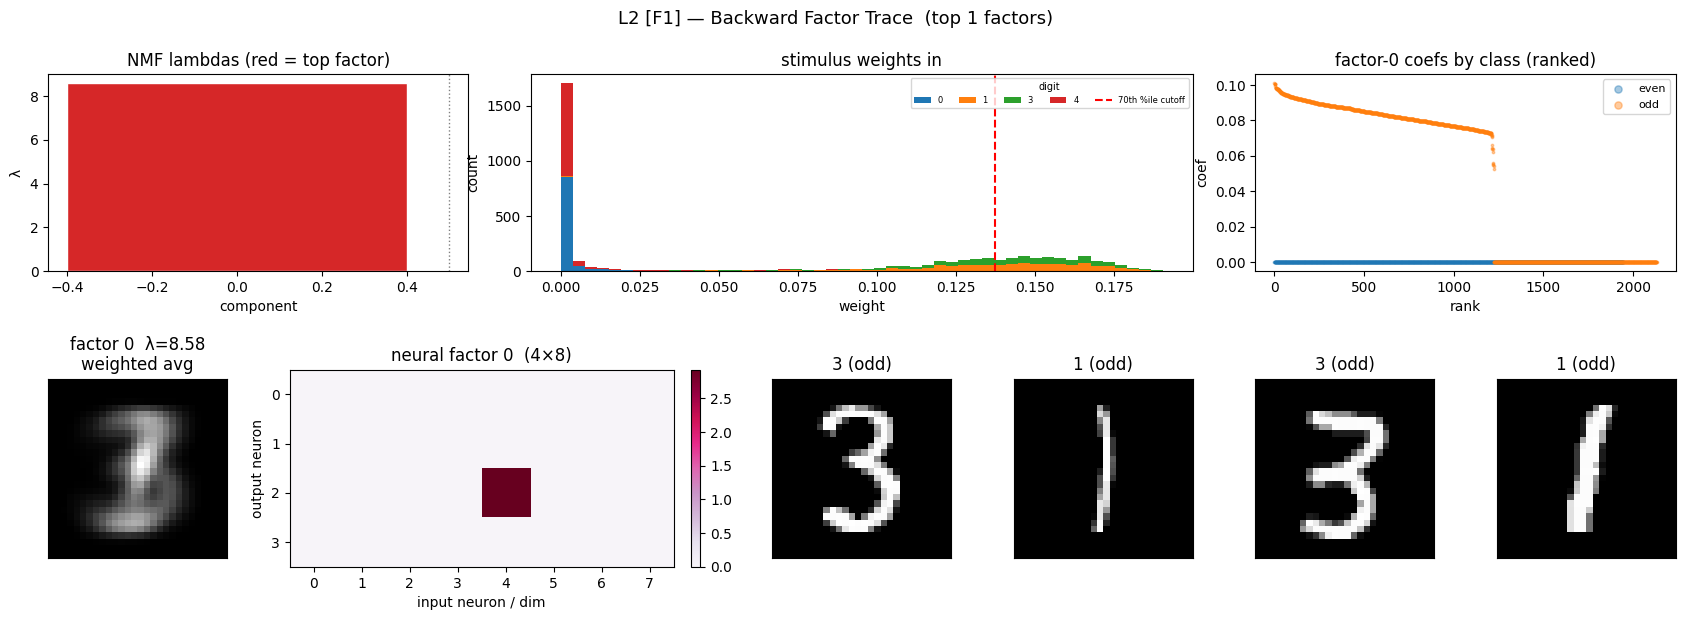

L2 — top 1 lambdas: [8.58]



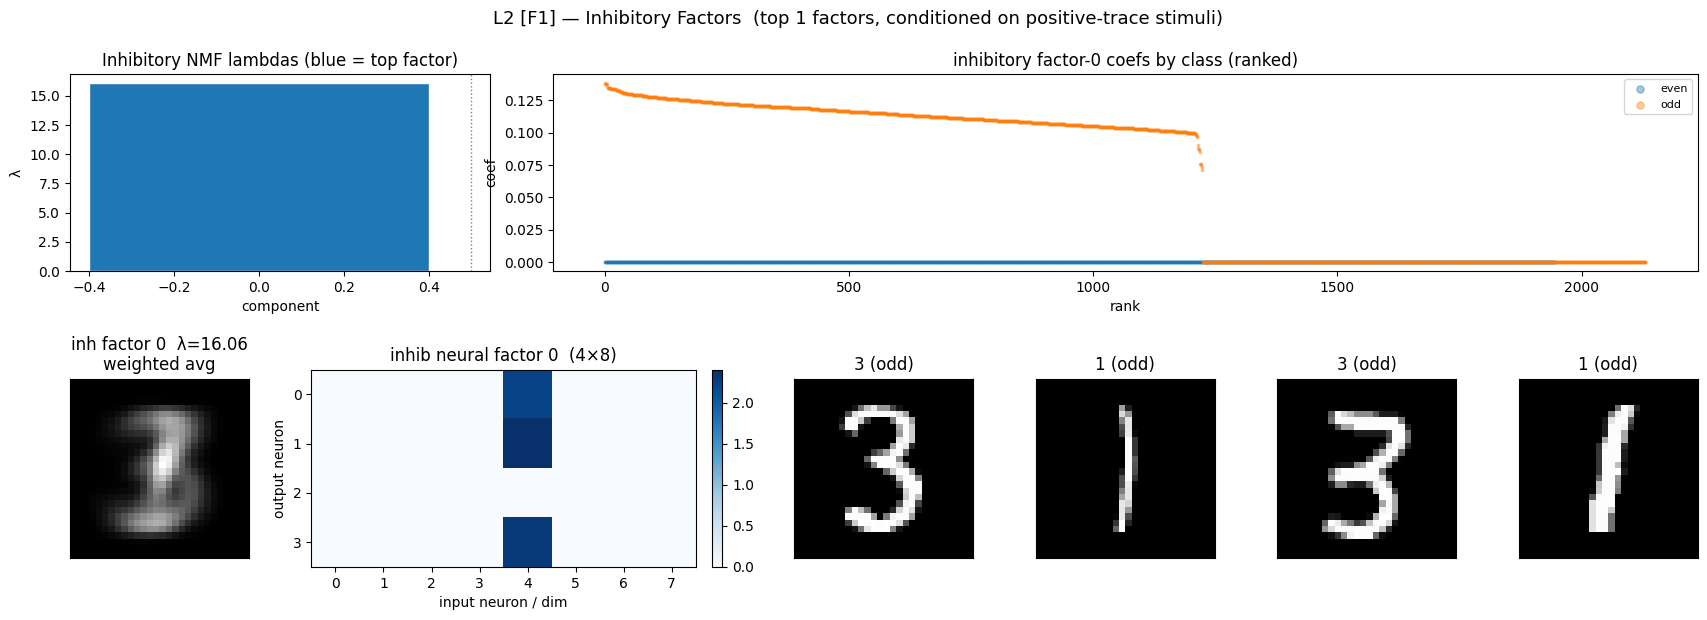

L2 inhibitory — top 1 lambdas: [16.06]



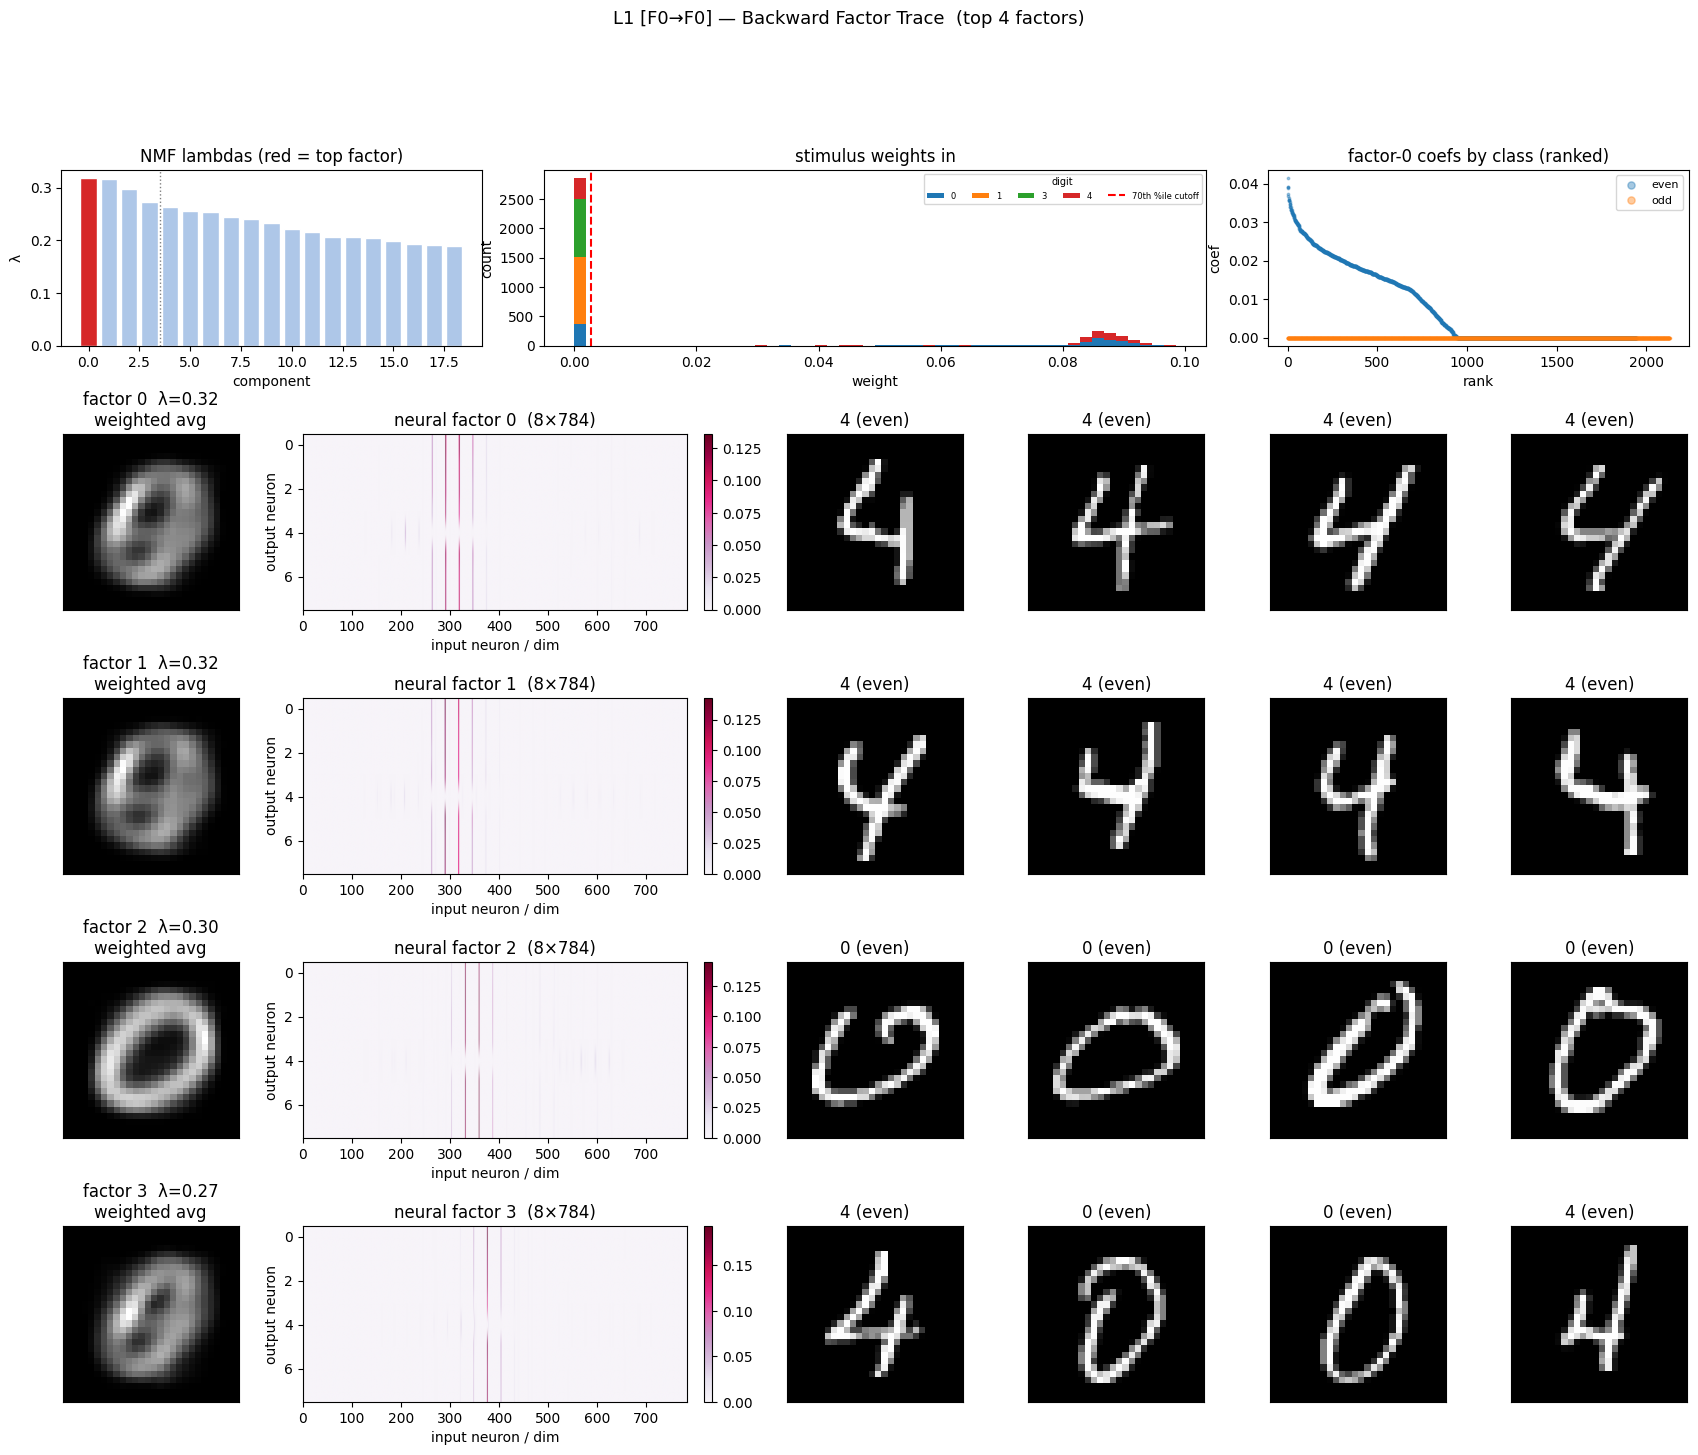

L1 — top 4 lambdas: [0.318 0.317 0.297 0.272]



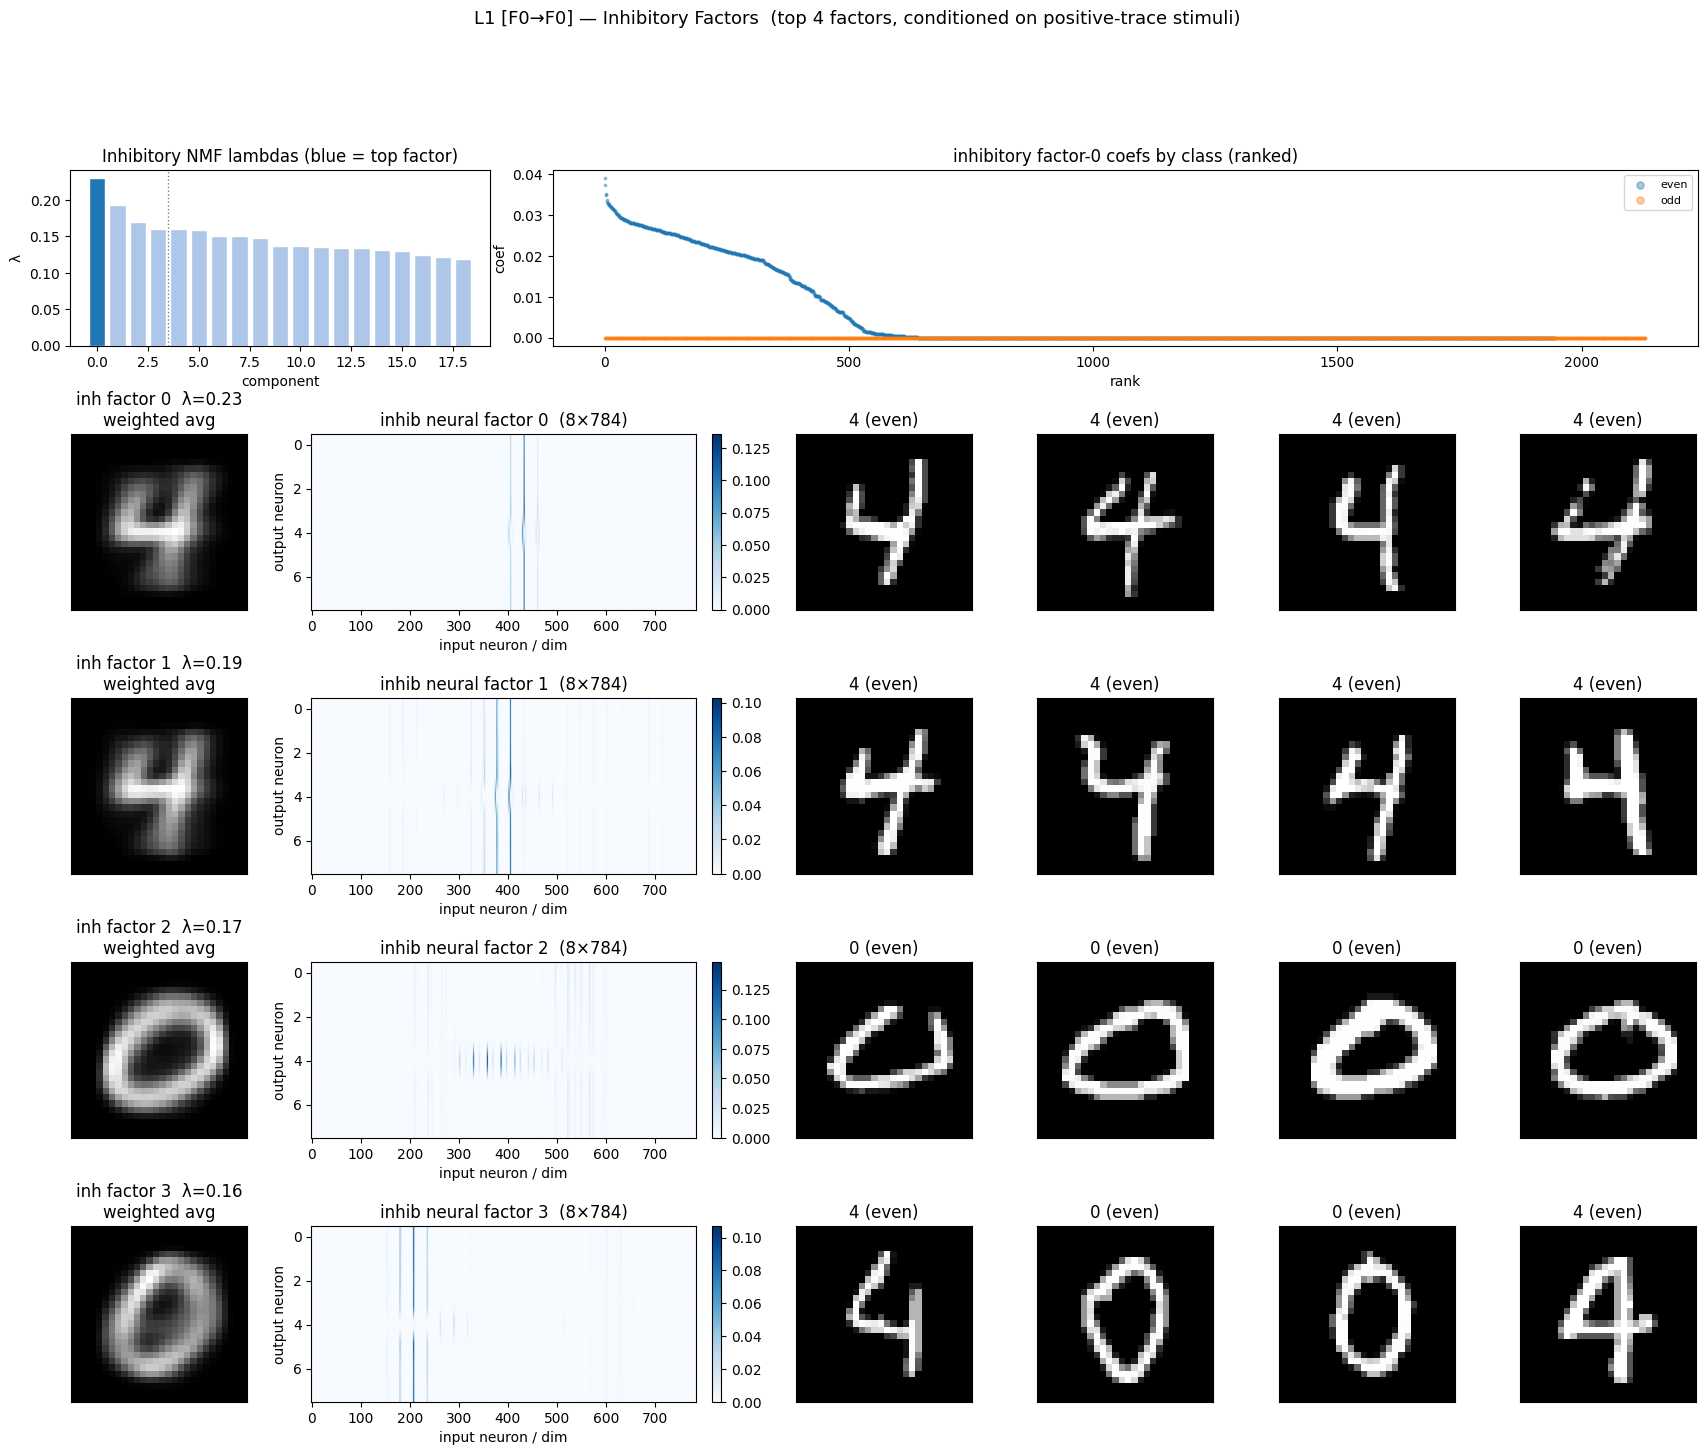

L1 inhibitory — top 4 lambdas: [0.23  0.193 0.17  0.16 ]



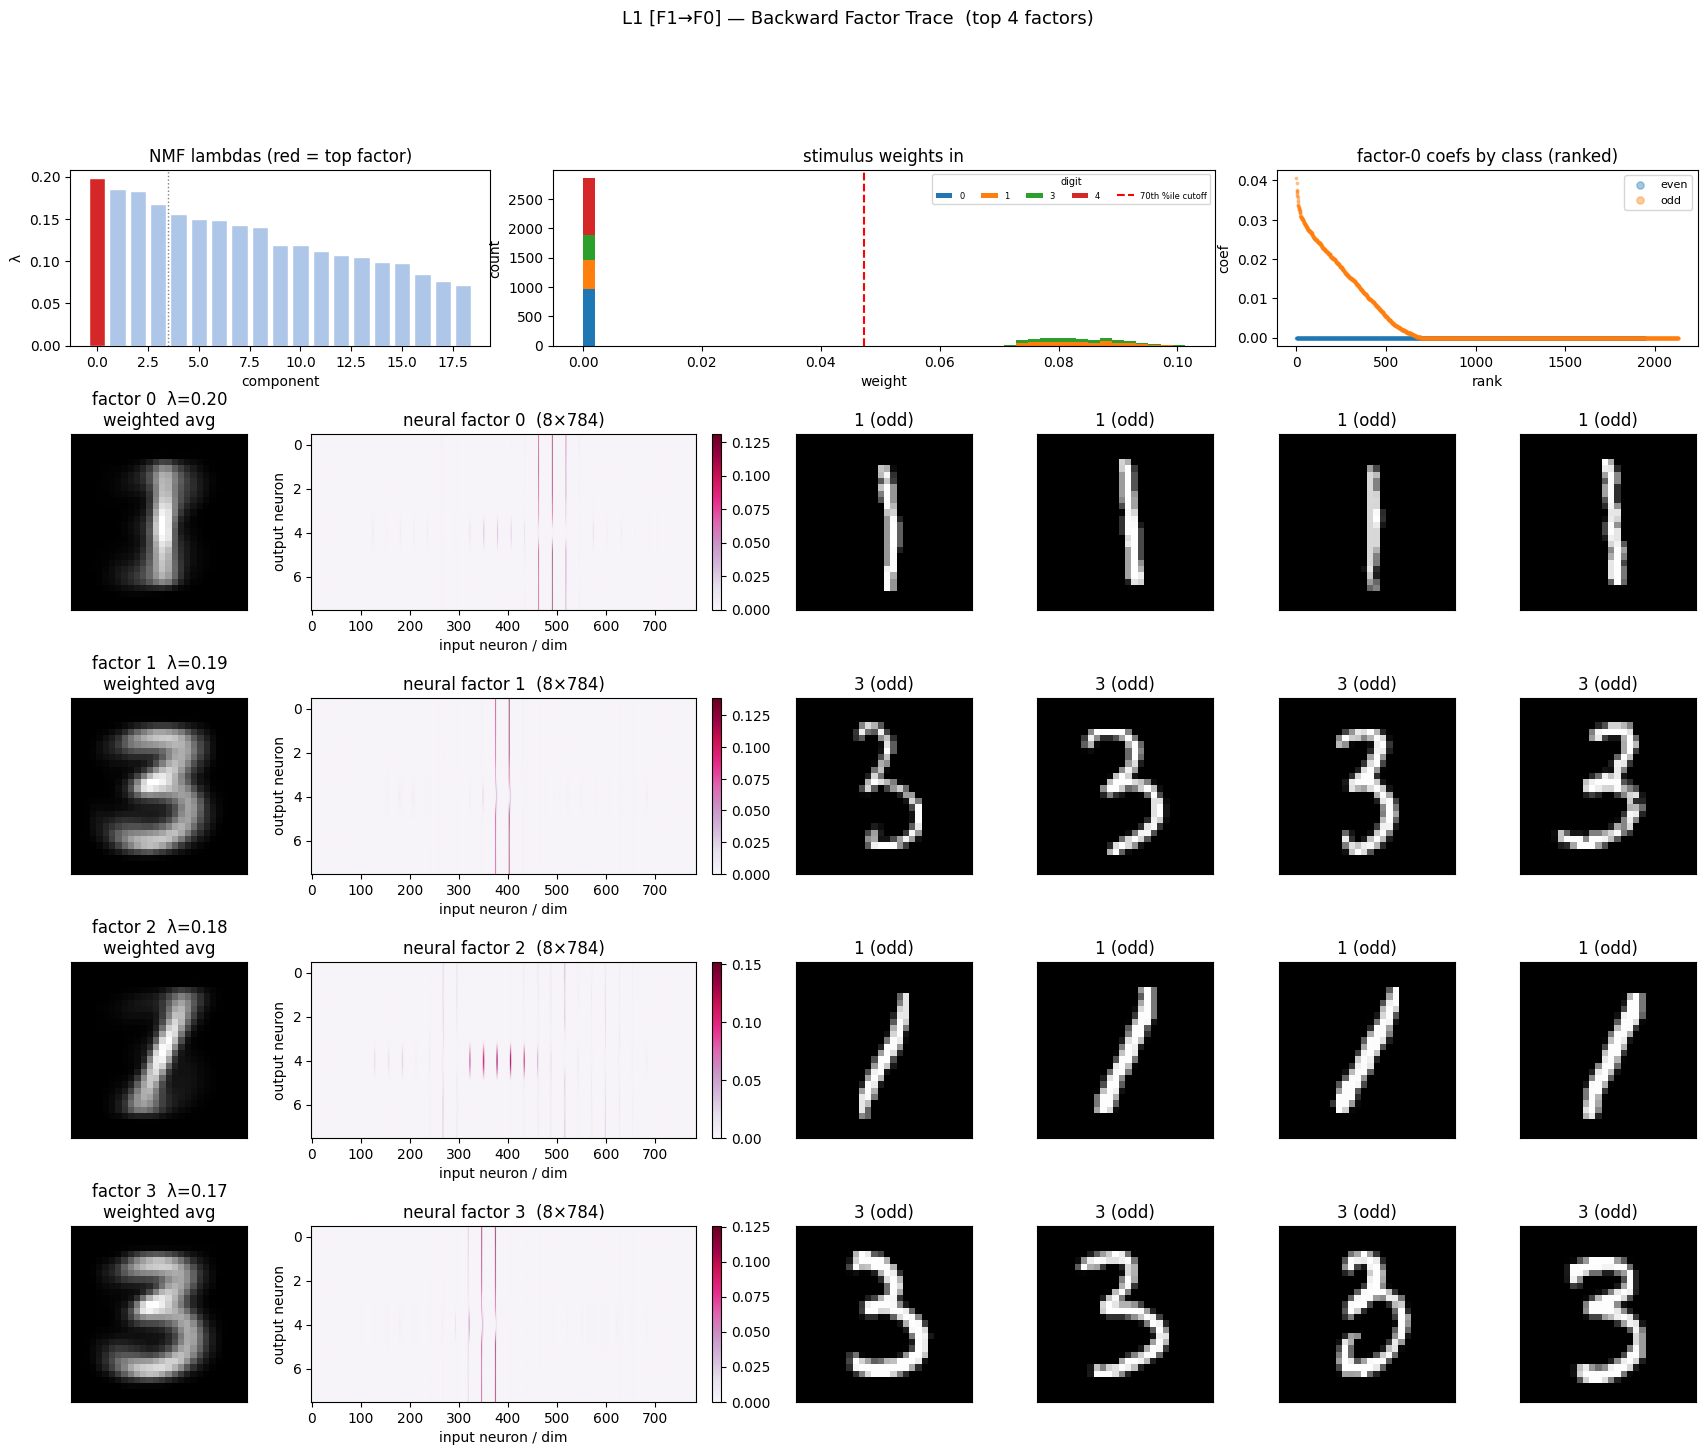

L1 — top 4 lambdas: [0.198 0.185 0.183 0.168]



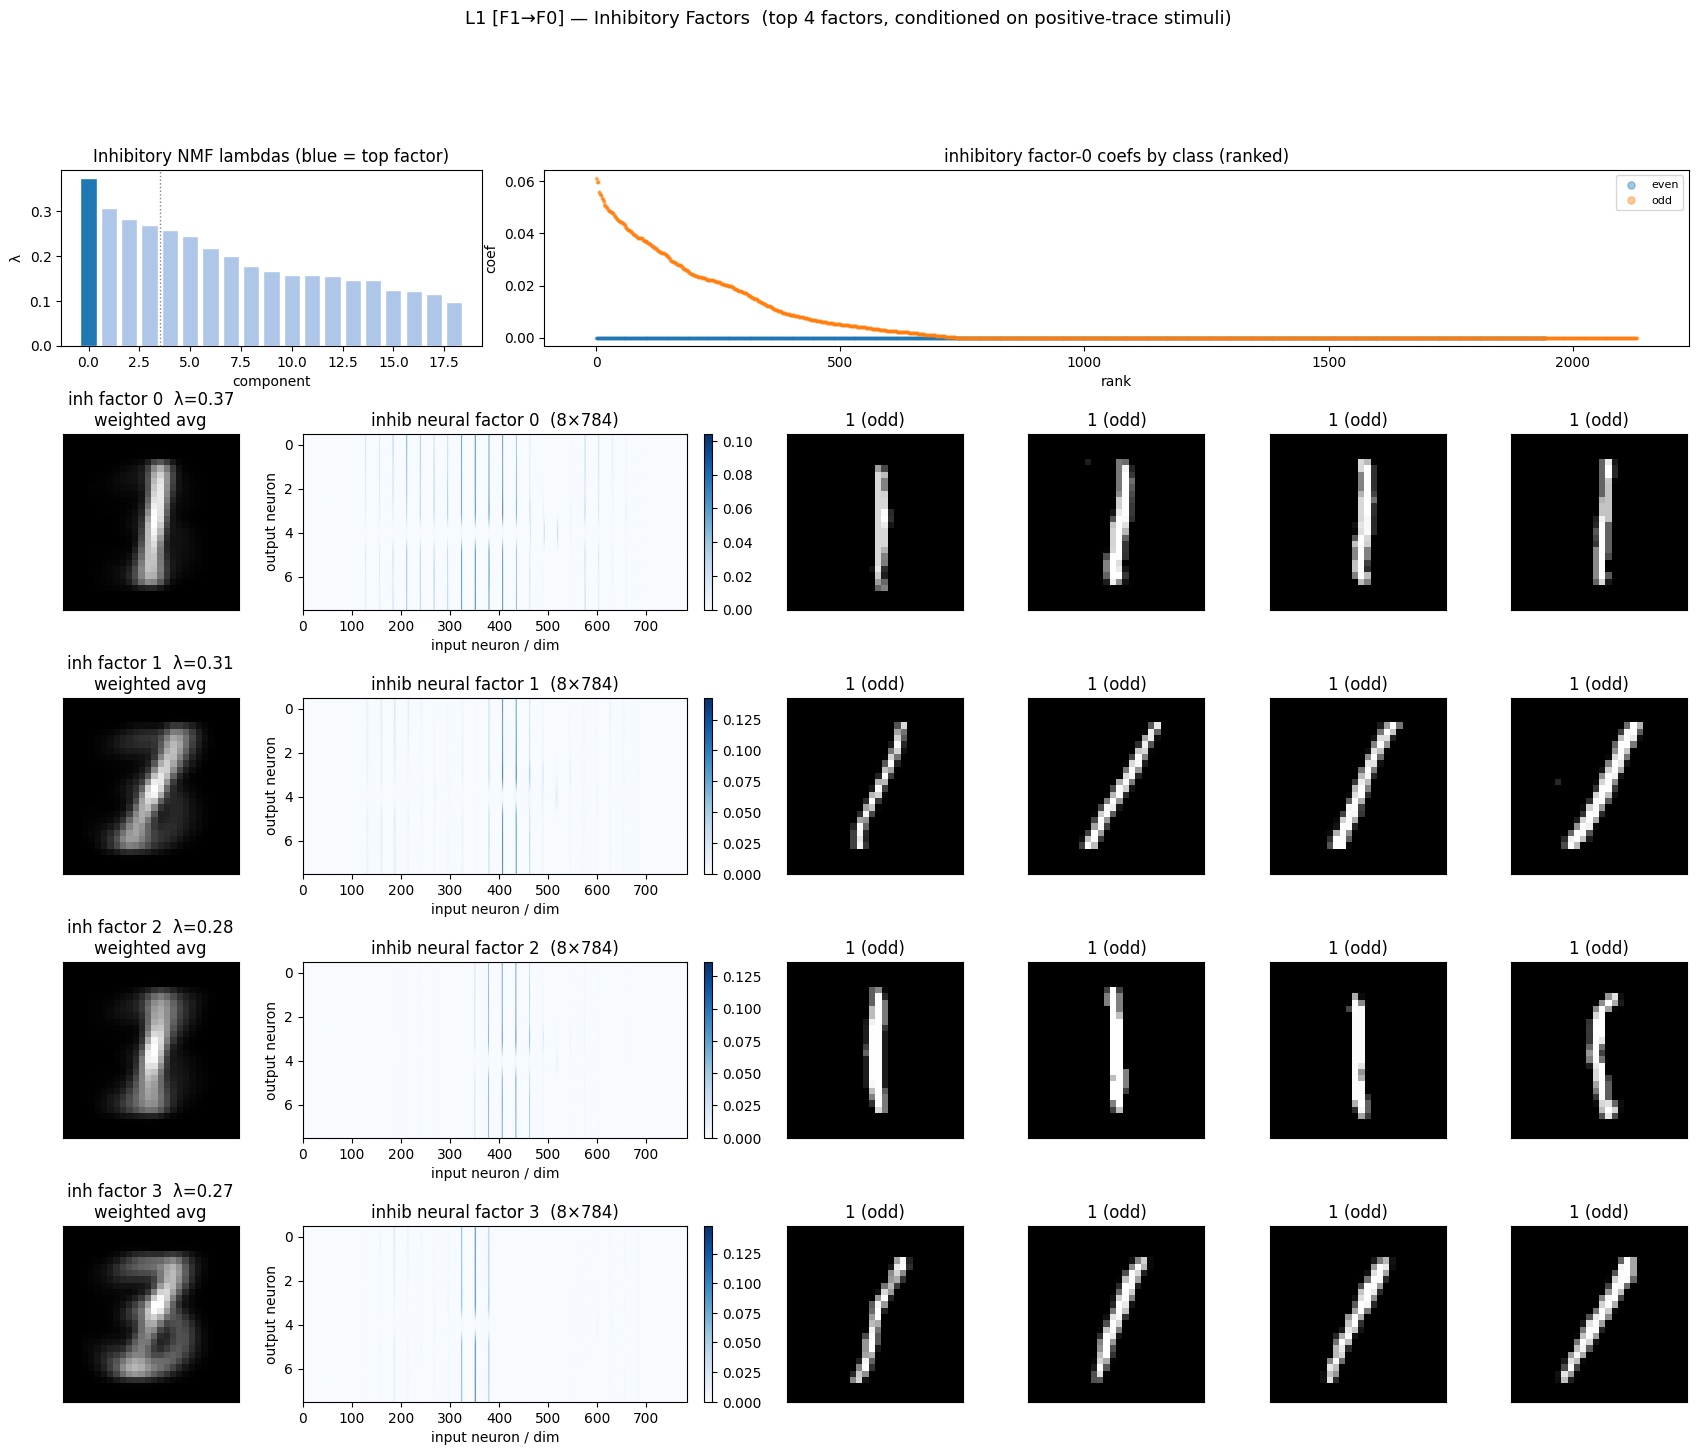

L1 inhibitory — top 4 lambdas: [0.373 0.306 0.282 0.269]



In [8]:
flat_imgs = all_images.reshape(n_samples, -1)

for depth in sorted(nodes_by_depth.keys()):
  for r in nodes_by_depth[depth]:
      l_idx = r['layer_idx']
      n_out, n_in = r['W'].shape
      img_f = r['img_factors']     # (n, K_actual)
      neu_f = r['neural_factors']  # (n_out * n_in, K_actual)
      lams  = r['lambdas']         # (K_actual,)
      n_show = min(N_VIZ, len(lams))

      fig = plt.figure(figsize=(21, 3.2 * (n_show + 1)))
      path_label = 'F' + '\u2192F'.join(str(f) for f in r['path']) if r['path'] else 'root'
      fig.suptitle(f'L{l_idx+1} [{path_label}] — Backward Factor Trace  (top {n_show} factors)', fontsize=13)
      gs = gridspec.GridSpec(n_show + 1, 7, figure=fig, hspace=0.5, wspace=0.35)

      # ── Row 0: overview ──────────────────────────────────────────────────────
      ax_lam = fig.add_subplot(gs[0, 0:2])
      bar_colors = ['#d62728'] + ['#aec7e8'] * (len(lams) - 1)
      ax_lam.bar(range(len(lams)), lams, color=bar_colors, edgecolor='white')
      ax_lam.axvline(n_show - 0.5, color='k', ls=':', lw=1, alpha=0.5)
      ax_lam.set(xlabel='component', ylabel='λ', title='NMF lambdas (red = top factor)')

      ax_hist = fig.add_subplot(gs[0, 2:5])
      sw = r['stimulus_weights_in']
      digits_unique = sorted(np.unique(all_digits))
      cmap_tab = matplotlib.colormaps['tab10']
      ax_hist.hist([sw[all_digits == d] for d in digits_unique], bins=50, stacked=True,
                   color=[cmap_tab(i) for i in range(len(digits_unique))],
                   label=[str(d) for d in digits_unique], edgecolor='none', lw=0)
      ax_hist.legend(fontsize=6, ncol=5, title='digit', title_fontsize=7)
      if STIMULUS_THRESHOLD > 0 and not np.allclose(sw, 1.0):
          cutoff = np.quantile(sw, STIMULUS_THRESHOLD)
          ax_hist.axvline(cutoff, color='r', ls='--', lw=1.5,
                          label=f'{STIMULUS_THRESHOLD*100:.0f}th %ile cutoff')
          ax_hist.legend(fontsize=6, ncol=5, title='digit', title_fontsize=7)
      ax_hist.set(title='stimulus weights in', xlabel='weight', ylabel='count')

      ax_cls = fig.add_subplot(gs[0, 5:7])
      cmap_tab = matplotlib.colormaps['tab10']
      for ci, cl in enumerate(sorted(np.unique(all_targets))):
          mask = all_targets == cl
          coefs_0 = img_f[mask, 0]
          ax_cls.scatter(np.arange(mask.sum()), np.sort(coefs_0)[::-1],
                         s=3, alpha=0.4, color=cmap_tab(ci),
                         label=CLASS_NAMES.get(cl, str(cl)))
      ax_cls.set(title='factor-0 coefs by class (ranked)', xlabel='rank', ylabel='coef')
      ax_cls.legend(markerscale=3, fontsize=8)

      # ── Factor rows ──────────────────────────────────────────────────────────
      for fi in range(n_show):
          coefs_k    = img_f[:, fi]
          per_neuron = neu_f[:, fi].reshape(n_out, n_in)

          # weighted average image
          ax_wav = fig.add_subplot(gs[fi + 1, 0])
          w_avg = (coefs_k[:, None] * flat_imgs).sum(0) / (coefs_k.sum() + 1e-12)
          ax_wav.imshow(w_avg.reshape(IMAGE_SIDE, IMAGE_SIDE), cmap='gray')
          ax_wav.set(title=f'factor {fi}  λ={lams[fi]:.2f}\nweighted avg', xticks=[], yticks=[])

          # neural factor heatmap
          ax_nf = fig.add_subplot(gs[fi + 1, 1:3])
          im = ax_nf.imshow(per_neuron, aspect='auto', cmap='PuRd')
          plt.colorbar(im, ax=ax_nf, fraction=0.046, pad=0.04)
          ax_nf.set(title=f'neural factor {fi}  ({n_out}×{n_in})',
                    xlabel='input neuron / dim', ylabel='output neuron')

          # top-4 sample images
          top_idx_k = np.argsort(coefs_k)[::-1][:4]
          for col_i, s_idx in enumerate(top_idx_k):
              ax_img = fig.add_subplot(gs[fi + 1, 3 + col_i])
              ax_img.imshow(all_images[s_idx].squeeze(), cmap='gray')
              d  = all_digits[s_idx]
              cl = all_targets[s_idx]
              ax_img.set(title=f'{d} ({CLASS_NAMES.get(cl, cl)})', xticks=[], yticks=[])

      _pl = path_label.replace('\u2192', '-')
      fig.savefig(os.path.join(FIG_FVIZ, f'L{l_idx+1}_{_pl}_positive.pdf'), bbox_inches='tight')
      plt.show()
      print(f'L{l_idx+1} — top {n_show} lambdas: {np.round(lams[:n_show], 3)}')
      print()

      # ── Inhibitory factors ───────────────────────────────────────────────────
      neg_img_f = r['neg_img_factors']
      neg_neu_f = r['neg_neural_factors']
      neg_lams  = r['neg_lambdas']
      if neg_lams is not None:
          n_show_neg = min(N_VIZ, len(neg_lams))
          fig2 = plt.figure(figsize=(21, 3.2 * (n_show_neg + 1)))
          fig2.suptitle(f'L{l_idx+1} [{path_label}] — Inhibitory Factors  (top {n_show_neg} factors, conditioned on positive-trace stimuli)', fontsize=13)
          gs2 = gridspec.GridSpec(n_show_neg + 1, 7, figure=fig2, hspace=0.5, wspace=0.35)

          ax_lam2 = fig2.add_subplot(gs2[0, 0:2])
          bar_colors2 = ['#1f77b4'] + ['#aec7e8'] * (len(neg_lams) - 1)
          ax_lam2.bar(range(len(neg_lams)), neg_lams, color=bar_colors2, edgecolor='white')
          ax_lam2.axvline(n_show_neg - 0.5, color='k', ls=':', lw=1, alpha=0.5)
          ax_lam2.set(xlabel='component', ylabel='λ', title='Inhibitory NMF lambdas (blue = top factor)')

          ax_cls2 = fig2.add_subplot(gs2[0, 2:7])
          for ci, cl in enumerate(sorted(np.unique(all_targets))):
              mask = all_targets == cl
              coefs_0 = neg_img_f[mask, 0]
              ax_cls2.scatter(np.arange(mask.sum()), np.sort(coefs_0)[::-1],
                              s=3, alpha=0.4, color=cmap_tab(ci),
                              label=CLASS_NAMES.get(cl, str(cl)))
          ax_cls2.set(title='inhibitory factor-0 coefs by class (ranked)', xlabel='rank', ylabel='coef')
          ax_cls2.legend(markerscale=3, fontsize=8)

          for fi in range(n_show_neg):
              coefs_k    = neg_img_f[:, fi]
              per_neuron = neg_neu_f[:, fi].reshape(n_out, n_in)

              ax_wav2 = fig2.add_subplot(gs2[fi + 1, 0])
              w_avg2 = (coefs_k[:, None] * flat_imgs).sum(0) / (coefs_k.sum() + 1e-12)
              ax_wav2.imshow(w_avg2.reshape(IMAGE_SIDE, IMAGE_SIDE), cmap='gray')
              ax_wav2.set(title=f'inh factor {fi}  \u03bb={neg_lams[fi]:.2f}\nweighted avg', xticks=[], yticks=[])

              ax_nf2 = fig2.add_subplot(gs2[fi + 1, 1:3])
              im2 = ax_nf2.imshow(per_neuron, aspect='auto', cmap='Blues')
              plt.colorbar(im2, ax=ax_nf2, fraction=0.046, pad=0.04)
              ax_nf2.set(title=f'inhib neural factor {fi}  ({n_out}\u00d7{n_in})',
                         xlabel='input neuron / dim', ylabel='output neuron')

              top_idx_k2 = np.argsort(coefs_k)[::-1][:4]
              for col_i, s_idx in enumerate(top_idx_k2):
                  ax_img2 = fig2.add_subplot(gs2[fi + 1, 3 + col_i])
                  ax_img2.imshow(all_images[s_idx].squeeze(), cmap='gray')
                  d  = all_digits[s_idx]
                  cl = all_targets[s_idx]
                  ax_img2.set(title=f'{d} ({CLASS_NAMES.get(cl, cl)})', xticks=[], yticks=[])

          fig2.savefig(os.path.join(FIG_FVIZ, f'L{l_idx+1}_{_pl}_inhibitory.pdf'), bbox_inches='tight')
          plt.show()
          print(f'L{l_idx+1} inhibitory — top {n_show_neg} lambdas: {np.round(neg_lams[:n_show_neg], 3)}')
          print()

## Section 5: Layer-1 Pixel Receptive Fields

At layer 1 the neural factor pattern has shape `(n_L1_neurons × 784,)`. Reshaping to `(n_neurons, 28, 28)` gives each L1 neuron's pixel-level receptive field for the traced factor.

We also show the raw weight matrices for comparison.

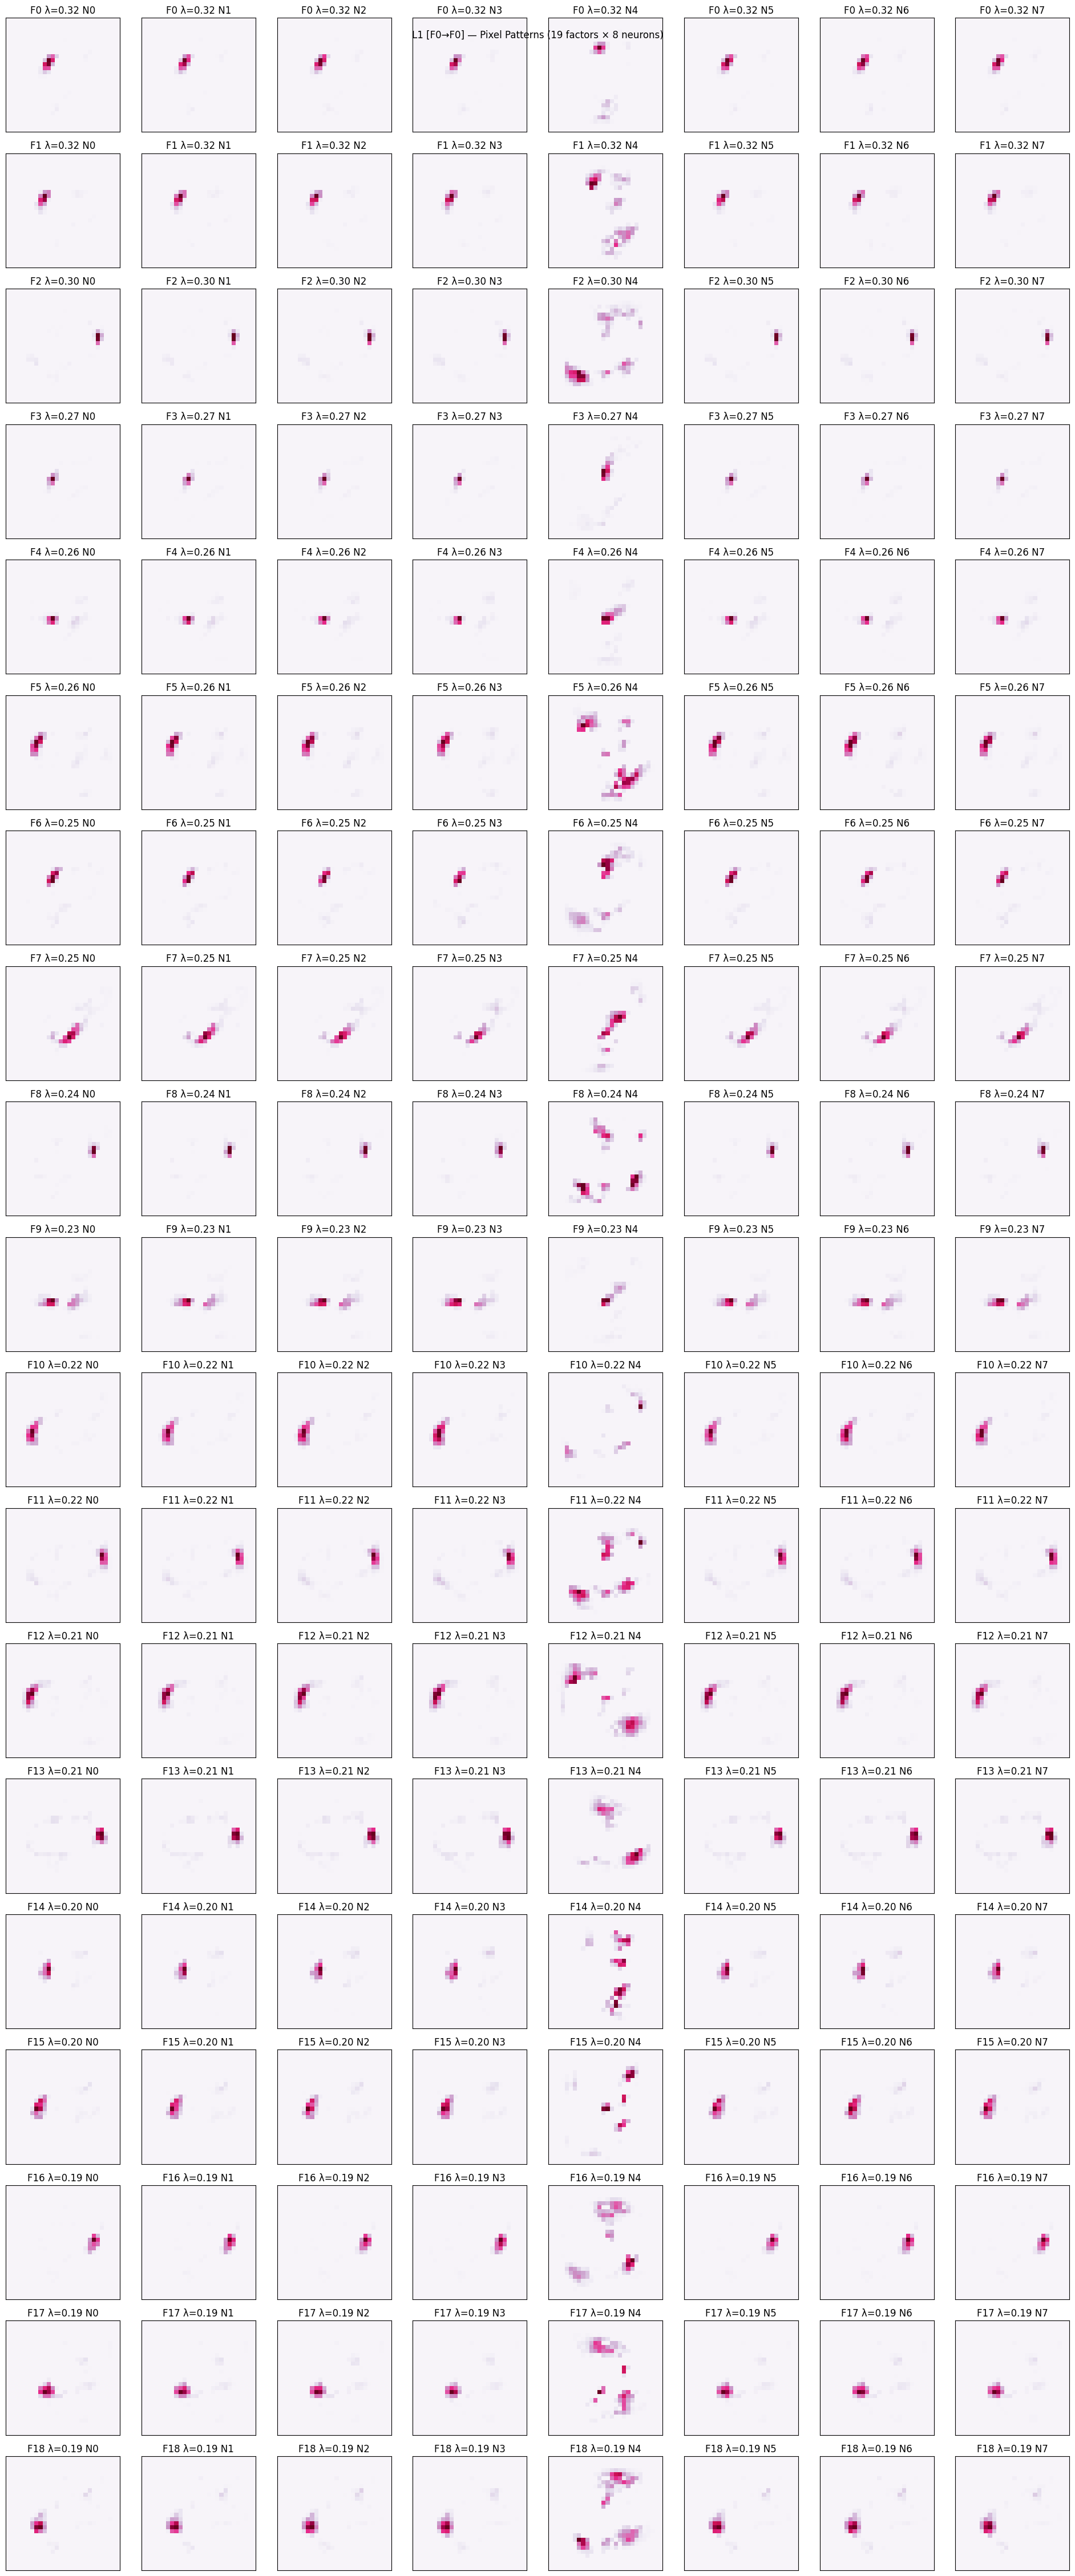

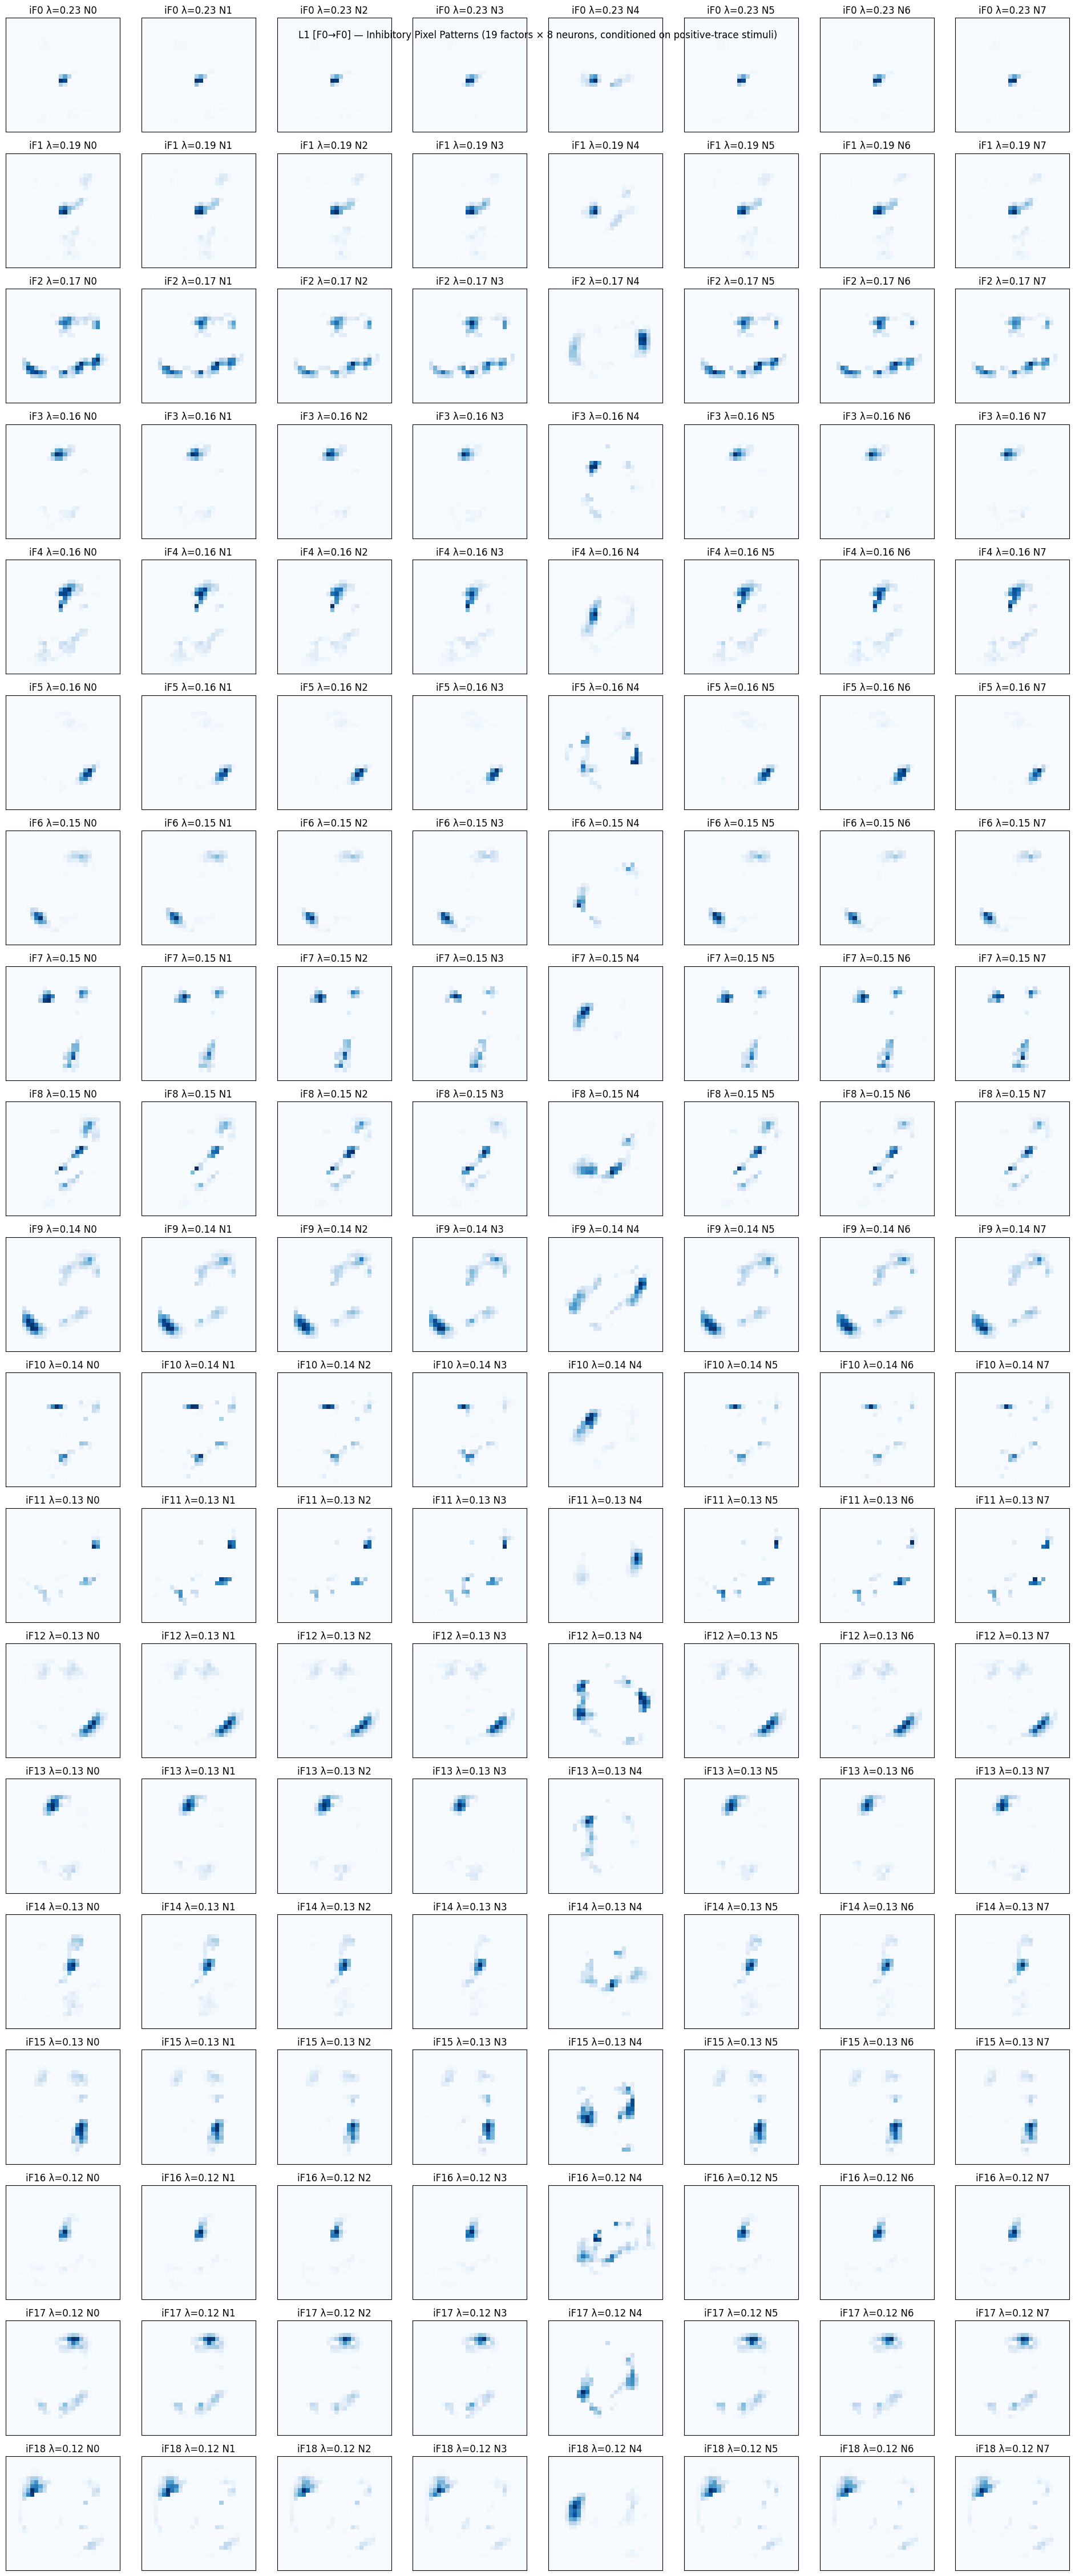

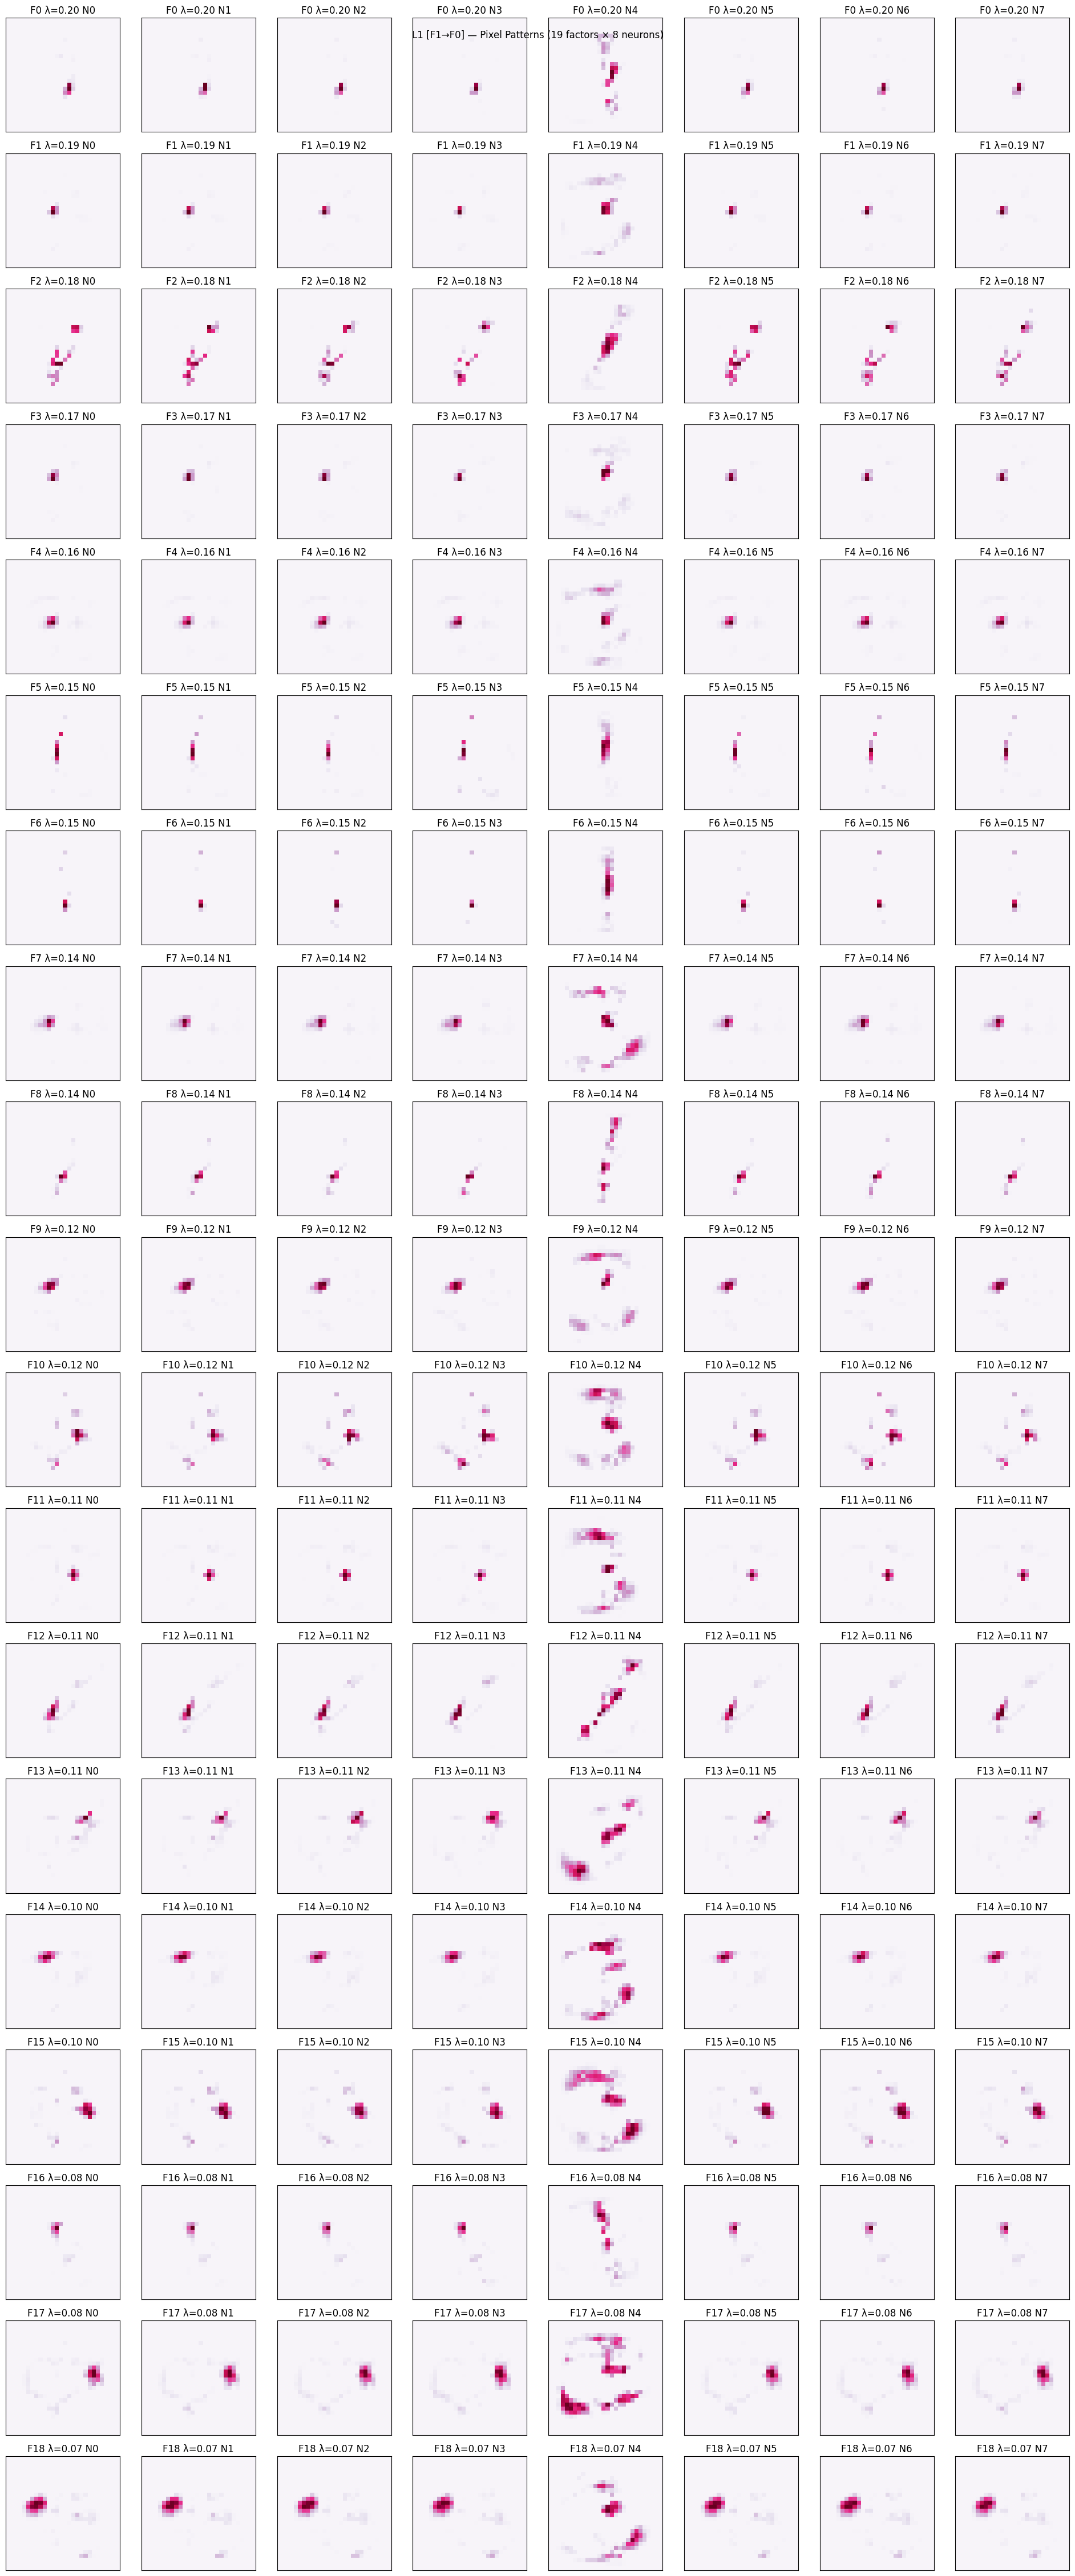

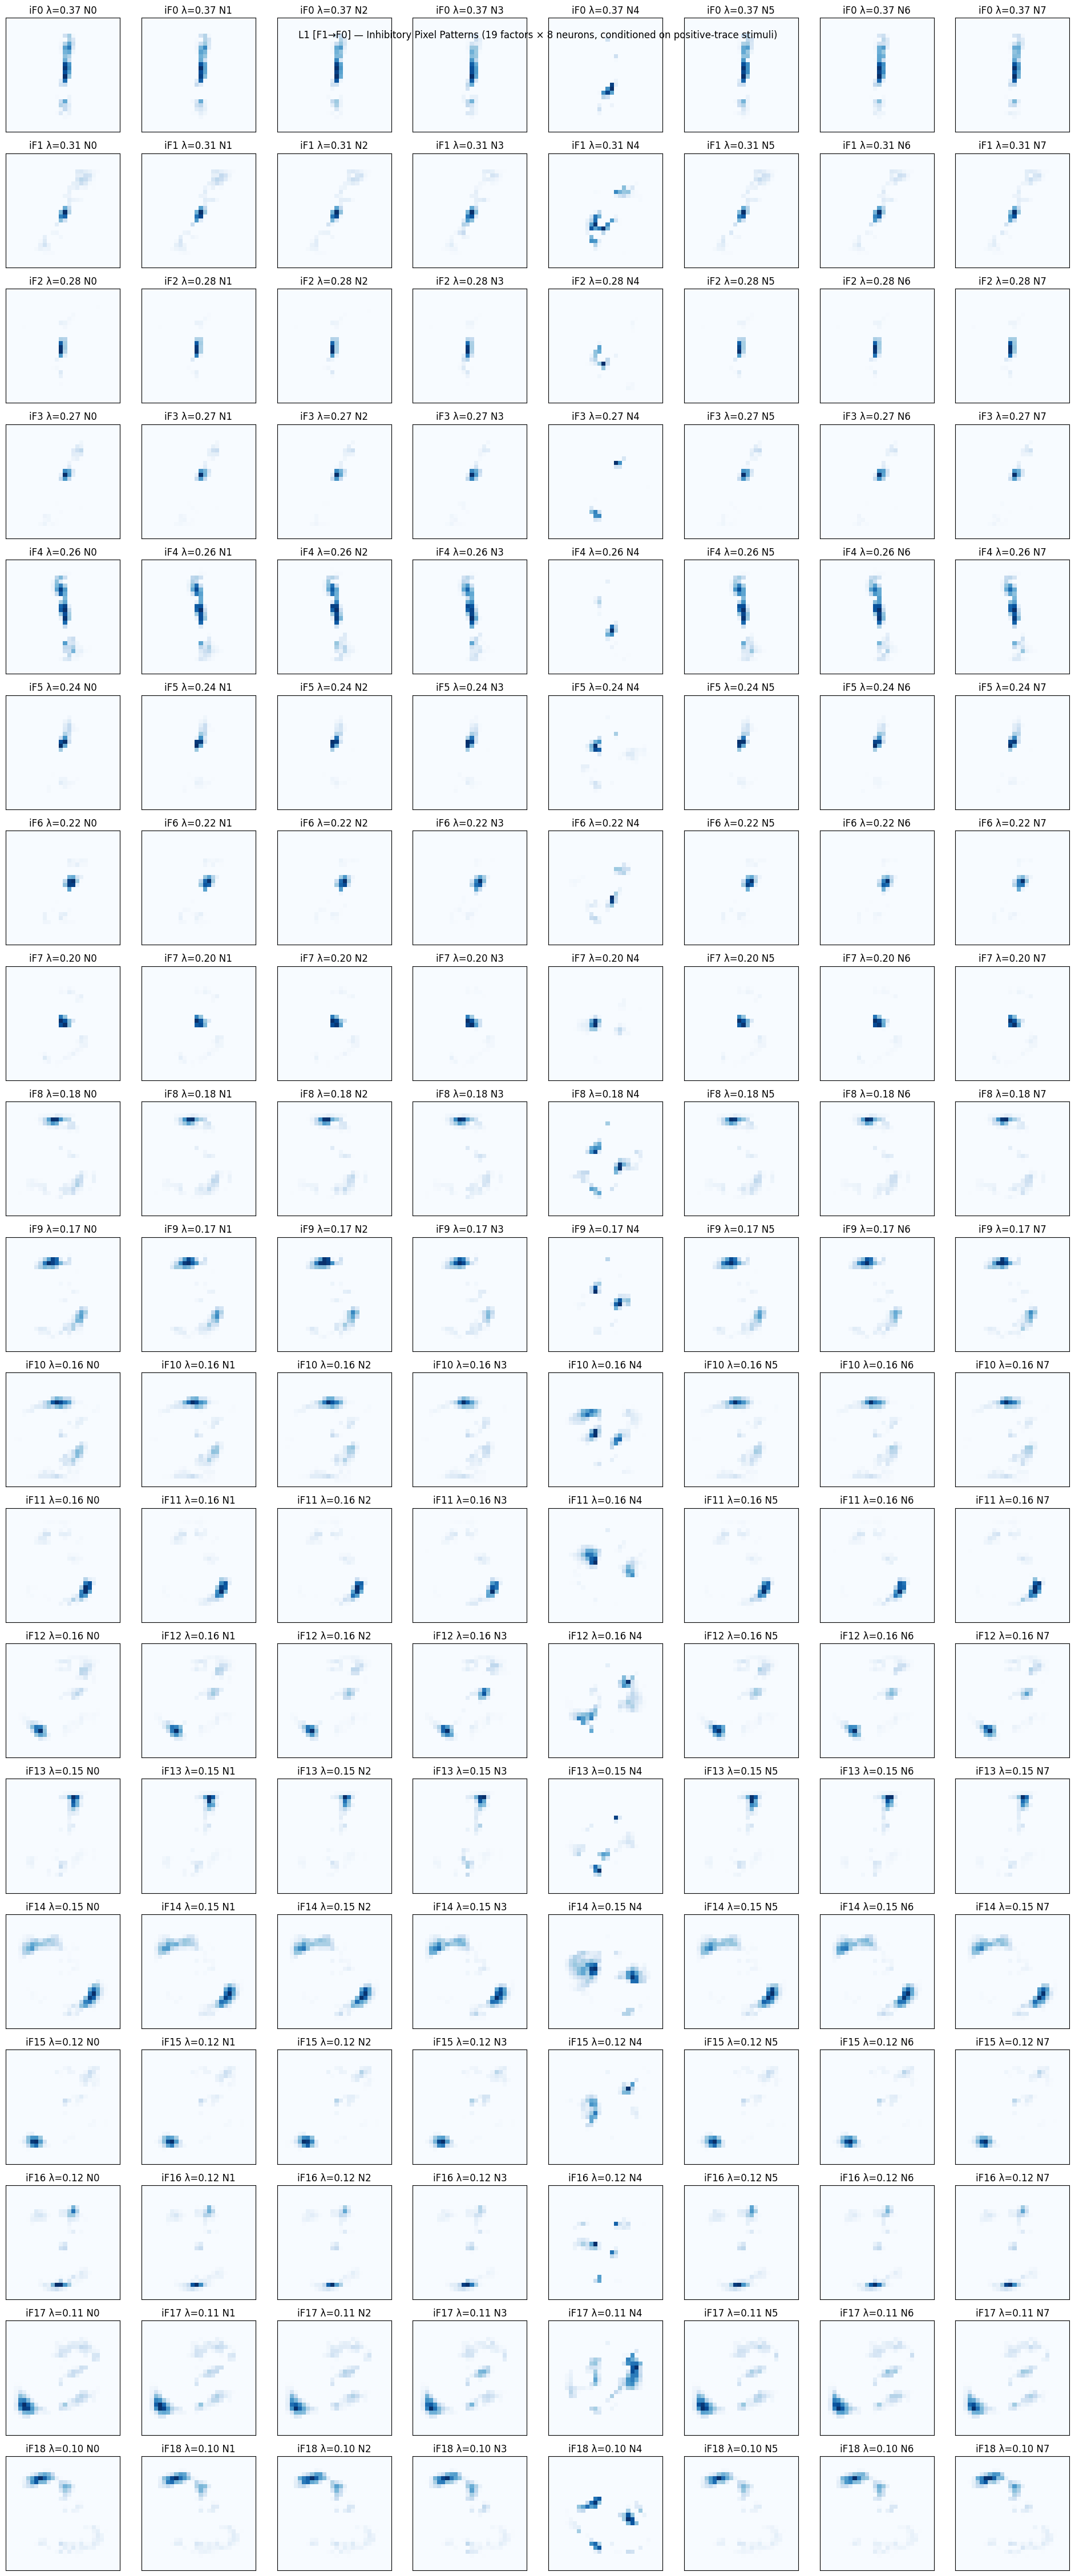

In [9]:
max_depth = max(nodes_by_depth.keys())

for r in nodes_by_depth[max_depth]:
    n_out_L1 = r['W'].shape[0]
    neu_f    = r['neural_factors']   # (n_out_L1 * 784, K)
    lams     = r['lambdas']
    K_actual = len(lams)
    path_label = 'F' + '\u2192F'.join(str(f) for f in r['path']) if r['path'] else 'root'

    ncols = n_out_L1
    nrows = K_actual
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.4, nrows * 2.4),
                             squeeze=False)
    fig.suptitle(f'L1 [{path_label}] \u2014 Pixel Patterns ({K_actual} factors \u00d7 {n_out_L1} neurons)', fontsize=12)

    for fi in range(K_actual):
        patterns = neu_f[:, fi].reshape(n_out_L1, IMAGE_SIDE, IMAGE_SIDE)
        for ni in range(n_out_L1):
            ax = axes[fi, ni]
            p  = patterns[ni]
            pmax = p.max() or 1
            ax.imshow(np.log1p(p / pmax * (np.e - 1)), cmap='PuRd', vmin=0, vmax=1)
            ax.set(title=f'F{fi} \u03bb={lams[fi]:.2f} N{ni}', xticks=[], yticks=[])

    plt.tight_layout()
    _pl = path_label.replace('\u2192', '-')
    fig.savefig(os.path.join(FIG_PIXRF, f'L1_{_pl}_positive.pdf'), bbox_inches='tight')
    plt.show()

    neg_neu_f = r['neg_neural_factors']
    neg_lams  = r['neg_lambdas']
    if neg_lams is not None:
        K_neg = len(neg_lams)
        fig2, axes2 = plt.subplots(K_neg, n_out_L1, figsize=(n_out_L1 * 2.4, K_neg * 2.4),
                                   squeeze=False)
        fig2.suptitle(f'L1 [{path_label}] — Inhibitory Pixel Patterns ({K_neg} factors × {n_out_L1} neurons, conditioned on positive-trace stimuli)', fontsize=12)
        for fi in range(K_neg):
            patterns2 = neg_neu_f[:, fi].reshape(n_out_L1, IMAGE_SIDE, IMAGE_SIDE)
            for ni in range(n_out_L1):
                ax2 = axes2[fi, ni]
                p2  = patterns2[ni]
                pmax2 = p2.max() or 1
                ax2.imshow(np.log1p(p2 / pmax2 * (np.e - 1)), cmap='Blues', vmin=0, vmax=1)
                ax2.set(title=f'iF{fi} λ={neg_lams[fi]:.2f} N{ni}', xticks=[], yticks=[])
        plt.tight_layout()
        fig2.savefig(os.path.join(FIG_PIXRF, f'L1_{_pl}_inhibitory.pdf'), bbox_inches='tight')
        plt.show()



## Section 6: Full Network Scaffold Graph

Build a layer-by-layer scaffold graph from the traced factors:

- **Nodes**: one per neuron; size/colour encodes importance (sum of arbor contributions)
- **Edges**: weight = `neural_factors[i*n_in + j, 0]` — the arbor strength from input neuron `j` to output neuron `i` in the top factor
- Positive edges shown in PuRd (pink/red)

Layers are ordered L1 (left) → L3 (right).

In [ ]:
def _realistic_neu(node, fi, img_key='img_factors', nf_key='neural_factors', top_pct=0.05):
    img_f = node[img_key]
    neu_f = node[nf_key]
    n_top = max(1, int(np.ceil(len(img_f) * top_pct)))
    top_idx = np.argsort(img_f[:, fi])[-n_top:]
    return (img_f[top_idx, :] @ neu_f.T).mean(axis=0)

for path_nodes in all_paths:
    layer_results = list(reversed(path_nodes))  # L1 first, L3 last

    edge_matrices = []
    neg_edge_matrices = []
    for b in range(N_LAYERS - 1):
        r_this  = layer_results[b]      # more-front layer
        r_above = layer_results[b + 1]  # layer above
        n_out_b, n_in_b = r_above['W'].shape
        fi = r_this['path'][-1]         # which factor of r_above seeded r_this
        edge = _realistic_neu(r_above, fi).reshape(n_out_b, n_in_b)
        edge_matrices.append(edge)
        neg_nf = r_above['neg_neural_factors']
        if neg_nf is not None and fi < neg_nf.shape[1]:
            neg_edge = _realistic_neu(r_above, fi, img_key='neg_img_factors',
                                      nf_key='neg_neural_factors').reshape(n_out_b, n_in_b)
        else:
            neg_edge = np.zeros((n_out_b, n_in_b))
        neg_edge_matrices.append(neg_edge)

    loading_parts = []
    for l_idx in range(N_LAYERS):
        if l_idx < N_LAYERS - 1:
            loading_parts.append(edge_matrices[l_idx].sum(axis=0))
        else:
            r = layer_results[l_idx]
            n_out, n_in = r['W'].shape
            fi_root = layer_results[l_idx - 1]['path'][-1]
            per_neuron = _realistic_neu(r, fi_root).reshape(n_out, n_in)
            loading_parts.append(per_neuron.sum(axis=1))
    loading = np.concatenate(loading_parts)

    path_label = 'F' + '→F'.join(str(f) for f in path_nodes[-1]['path'])

    print('LAYER_SIZES:', LAYER_SIZES)
    print('loading shape:', loading.shape, ' (should match sum of LAYER_SIZES)')
    for b, E in enumerate(edge_matrices):
        print(f'edge_matrices[{b}] shape: {E.shape}  '
              f'(L{b+2} neurons × L{b+1} neurons)')

    fig = plot_scaffold_graph(loading, edge_matrices, LAYER_SIZES, neg_edge_matrices=neg_edge_matrices)
    fig.suptitle(
        f'Factor Trace — Network Scaffold  [path: {path_label}]\n'
        '(NMF factor at each layer, traced backwards from output)',
        fontsize=11
    )

    ax = fig.axes[0]
    for li, sz in enumerate(LAYER_SIZES):
        ax.text(li, -0.3, f'L{li+1}\n({sz})', ha='center', va='top',
                fontsize=9, transform=ax.transData)

    plt.tight_layout()
    _pl = path_label.replace('→', '-')
    fig.savefig(os.path.join(FIG_SCAFF, f'scaffold_{_pl}.pdf'), bbox_inches='tight')
    plt.show()
